In [188]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import Point, LineString, Polygon, MultiPoint, mapping
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import plotly.express as px

In [2]:
# for the langoid CSV file 
df = pd.read_csv("glottolog_languoid.csv/languoid.csv") 
df.head() 

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [3]:
df.columns

Index(['id', 'family_id', 'parent_id', 'name', 'bookkeeping', 'level',
       'latitude', 'longitude', 'iso639P3code', 'description',
       'markup_description', 'child_family_count', 'child_language_count',
       'child_dialect_count', 'country_ids'],
      dtype='str')

In [4]:
# above, it seems that the name, level, latitude, longitude, and iso639P3code are all relevant

In [5]:
tamil = df[df["name"] == "Tamil"]
tamil

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
22917,tami1289,drav1251,tami1300,Tamil,False,language,10.520219,78.825989,tam,NaN,NaN,0,0,18,IN LK


In [6]:
malayalam = df[df["name"] == "Malayalam"]
malayalam

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
13316,mala1464,drav1251,mala1541,Malayalam,False,language,9.59208,76.7651,mal,NaN,NaN,0,0,13,IN


In [7]:
## above it appears that we got our coordinates
## now we gotta turn the latitude and longitude to a geographical object and place it on a map surface 

In [8]:
tamil_longitude_val = tamil["longitude"].iloc[0]
tamil_latitude_val = tamil["latitude"].iloc[0]
# created a geometric object in coordinate space 
tamil_point = Point(tamil_longitude_val, tamil_latitude_val)

In [9]:
type(tamil_point)

shapely.geometry.point.Point

In [10]:
## need to put the point into a geodataframe 
tamil_gdf = gpd.GeoDataFrame(
    {
        "name": ["Tamil"],
        "iso": ["tam"],
        "geometry": [tamil_point]
    },
    crs="EPSG:4326"
)

In [11]:
tamil_gdf

,name,iso,geometry
0,Tamil,tam,POINT (78.82599 10.52022)


In [12]:
type(tamil_gdf)

geopandas.geodataframe.GeoDataFrame

In [13]:
### NOW TO GET A POLYGON LAYER (INDIA) 
india_states = gpd.read_file("gadm41_IND_shp/gadm41_IND_1.shp") 
india_states.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,NA,"MULTIPOLYGON (((93.79078 6.85139, 93.79092 6.8..."
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,IN-AP,"MULTIPOLYGON (((78.73952 13.04549, 78.73218 13..."
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,IN-AR,"POLYGON ((95.3683 27.10736, 95.37366 27.108, 9..."
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,NA,"POLYGON ((94.19125 27.49632, 94.1869 27.49081,..."
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,IN-AS,"POLYGON ((92.7545 24.50112, 92.75133 24.49437,..."


In [14]:
import os
os.getcwd()

'/Users/sridevihariharan/Documents/URAP Box Files/Shape Files + Geographical Distribution of Dravidian Languages'

In [15]:
### filtering for Tamil Nadu polygon  
tamil_nadu = india_states[india_states["NAME_1"] == "Tamil Nadu"]

In [16]:
# polygon layer for Tamil Nadu
tamil_nadu

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
33,IND.31_1,IND,India,Tamil Nadu,Madras|Tamilnad,NA,State,State,NA,IN.TN,IN-TN,"MULTIPOLYGON (((77.55597 8.07708, 77.55597 8.0..."


Text(158.48310160923913, 0.5, 'Latitude (°E)')

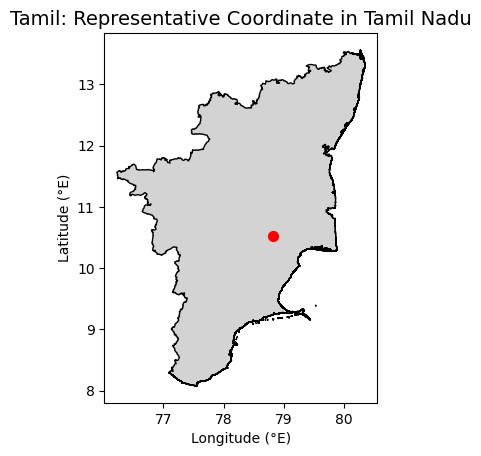

In [17]:
# plotting the polygon 
ax = tamil_nadu.plot(color="lightgrey", edgecolor="black")
# plotting the tamil gdf 
tamil_gdf.plot(ax=ax, color="red", markersize=50)
ax.set_title("Tamil: Representative Coordinate in Tamil Nadu", fontsize=14)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°E)")

In [18]:
### let's try to turn Malayalam into a geographical object now too  
malayalam_longitude_val = malayalam["longitude"].iloc[0]
malayalam_latitude_val = malayalam["latitude"].iloc[0]
# created a geometric object in coordinate space 
malayalam_point = Point(malayalam_longitude_val, malayalam_latitude_val)

In [19]:
type(malayalam_point)

shapely.geometry.point.Point

In [20]:
## need to put the point into a geodataframe 
malayalam_gdf = gpd.GeoDataFrame(
    {
        "name": ["Malayalam"],
        "iso": ["mal"],
        "geometry": [malayalam_point]
    },
    crs="EPSG:4326"
)

In [21]:
malayalam_gdf

,name,iso,geometry
0,Malayalam,mal,POINT (76.7651 9.59208)


In [22]:
kerala_state = india_states[india_states["NAME_1"] == "Kerala"]
kerala_state

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
19,IND.17_1,IND,India,Kerala,NA,NA,State,State,NA,IN.KL,IN-KL,"MULTIPOLYGON (((77.25153 8.57099, 77.2597 8.54..."


Text(192.38643661283254, 0.5, 'Latitude (°E)')

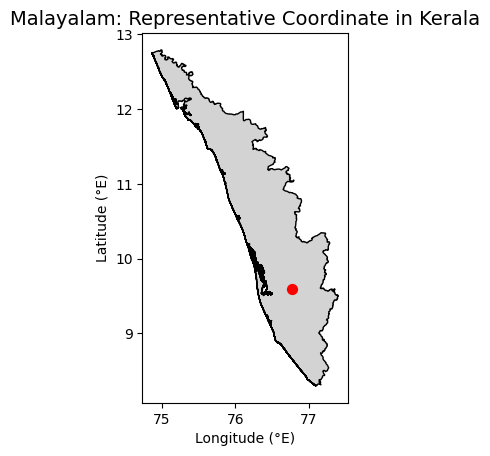

In [23]:
# plotting the polygon 
ax = kerala_state.plot(color="lightgrey", edgecolor="black")
# plotting the tamil gdf 
malayalam_gdf.plot(ax=ax, color="red", markersize=50)
ax.set_title("Malayalam: Representative Coordinate in Kerala", fontsize=14)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°E)")

In [24]:
df_lang = pd.read_csv("census_data.csv")
df_lang.head()

,state,language,speakers
0,Tamil Nadu,Tamil,69026881
1,Kerala,Malayalam,34838819
2,Andhra Pradesh,Telugu,81127740
3,Karnataka,Kannada,43706512


In [25]:
merged = india_states.merge(df_lang, left_on="NAME_1", right_on="state")
merged.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,state,language,speakers
0,IND.16_1,IND,India,Karnataka,Maisur|Mysore,NA,State,State,NA,IN.KA,IN-KA,"MULTIPOLYGON (((76.081 11.96067, 76.07281 11.9...",Karnataka,Kannada,43706512
1,IND.17_1,IND,India,Kerala,NA,NA,State,State,NA,IN.KL,IN-KL,"MULTIPOLYGON (((77.25153 8.57099, 77.2597 8.54...",Kerala,Malayalam,34838819
2,IND.31_1,IND,India,Tamil Nadu,Madras|Tamilnad,NA,State,State,NA,IN.TN,IN-TN,"MULTIPOLYGON (((77.55597 8.07708, 77.55597 8.0...",Tamil Nadu,Tamil,69026881


In [26]:
india_states["NAME_1"].unique()

<StringArray>
[   'Andaman and Nicobar',         'Andhra Pradesh',      'Arunachal Pradesh',
                  'Assam',                  'Bihar',             'Chandigarh',
           'Chhattisgarh', 'Dadra and Nagar Haveli',          'Daman and Diu',
                    'Goa',                'Gujarat',                'Haryana',
       'Himachal Pradesh',      'Jammu and Kashmir',              'Jharkhand',
              'Karnataka',                 'Kerala',            'Lakshadweep',
         'Madhya Pradesh',            'Maharashtra',                'Manipur',
              'Meghalaya',                'Mizoram',               'Nagaland',
           'NCT of Delhi',                 'Odisha',             'Puducherry',
                 'Punjab',              'Rajasthan',                 'Sikkim',
             'Tamil Nadu',              'Telangana',                'Tripura',
          'Uttar Pradesh',            'Uttarakhand',            'West Bengal']
Length: 36, dtype: str

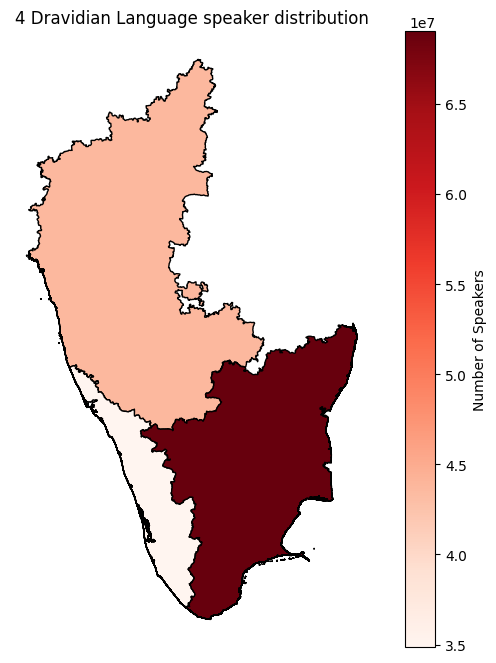

In [27]:
fig, ax = plt.subplots(figsize=(8,8))

merged.plot(
    column="speakers",
    cmap="Reds",
    legend=True,
    ax=ax, 
    edgecolor="black",
    legend_kwds={"label": "Number of Speakers"}
)

ax.set_title("4 Dravidian Language speaker distribution", fontsize=12)
ax.set_axis_off()

plt.show()

In [28]:
### Now what I want to do is get district level shapefiles, need to search GADM - Natural Earth - Datameet and find a json file 

## json file found 
districts = gpd.read_file("gadm41_IND_2.json")

In [29]:
districts.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IND.1.1_1,IND,India,IND.1_1,AndamanandNicobar,NA,NicobarIslands,NA,NA,District,District,NA,IN.AN.NI,"MULTIPOLYGON (((93.7899 6.852, 93.7909 6.851, ..."
1,IND.1.2_1,IND,India,IND.1_1,AndamanandNicobar,NA,NorthandMiddleAndaman,NA,NA,District,District,NA,IN.AN.NM,"MULTIPOLYGON (((92.8444 12.1497, 92.8461 12.15..."
2,IND.1.3_1,IND,India,IND.1_1,AndamanandNicobar,NA,SouthAndaman,NA,NA,District,District,NA,IN.AN.SA,"MULTIPOLYGON (((92.5211 10.8969, 92.53 10.8869..."
3,IND.2.1_1,IND,India,IND.2_1,AndhraPradesh,NA,Anantapur,"Anantpur,Ananthapur",NA,District,District,NA,IN.AD.AN,"MULTIPOLYGON (((77.846 13.9283, 77.8301 13.927..."
4,IND.2.2_1,IND,India,IND.2_1,AndhraPradesh,NA,Chittoor,Chitoor|Chittor,NA,District,District,NA,IN.AD.CH,"MULTIPOLYGON (((78.5455 12.7439, 78.5503 12.73..."


In [30]:
districts["NAME_1"].unique()

<StringArray>
[  'AndamanandNicobar',       'AndhraPradesh',    'ArunachalPradesh',
               'Assam',               'Bihar',          'Chandigarh',
        'Chhattisgarh', 'DadraandNagarHaveli',         'DamanandDiu',
                 'Goa',             'Gujarat',             'Haryana',
     'HimachalPradesh',     'JammuandKashmir',           'Jharkhand',
           'Karnataka',              'Kerala',         'Lakshadweep',
       'MadhyaPradesh',         'Maharashtra',             'Manipur',
           'Meghalaya',             'Mizoram',            'Nagaland',
          'NCTofDelhi',              'Odisha',          'Puducherry',
              'Punjab',           'Rajasthan',              'Sikkim',
           'TamilNadu',           'Telangana',             'Tripura',
        'UttarPradesh',         'Uttarakhand',          'WestBengal']
Length: 36, dtype: str

In [31]:
districts["NAME_1"] == "AndhraPradesh"

0      False
1      False
2      False
3       True
4       True
       ...  
671    False
672    False
673    False
674    False
675    False
Name: NAME_1, Length: 676, dtype: bool

In [32]:
(districts["NAME_1"] == "Kerala").any()

np.True_

In [33]:
## want to see data that is about Kerala districts
districts[districts["NAME_1"] == "Kerala"]

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
281,IND.17.1_1,IND,India,IND.17_1,Kerala,NA,Alappuzha,Alleppey,NA,District,District,NA,IN.KL.AL,"MULTIPOLYGON (((76.6292 9.2071, 76.6296 9.204,..."
282,IND.17.2_1,IND,India,IND.17_1,Kerala,NA,Ernakulam,NA,NA,District,District,NA,IN.KL.ER,"MULTIPOLYGON (((76.3771 9.8404, 76.3749 9.8376..."
283,IND.17.3_1,IND,India,IND.17_1,Kerala,NA,Idukki,Idikki,NA,District,District,NA,IN.KL.ID,"MULTIPOLYGON (((77.1991 10.0707, 77.2044 10.06..."
284,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07..."
285,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194..."
286,IND.17.6_1,IND,India,IND.17_1,Kerala,NA,Kollam,Quilon,NA,District,District,NA,IN.KL.KL,"MULTIPOLYGON (((76.7019 9.0769, 76.7096 9.0743..."
287,IND.17.7_1,IND,India,IND.17_1,Kerala,NA,Kottayam,NA,NA,District,District,NA,IN.KL.KT,"MULTIPOLYGON (((76.4954 9.4086, 76.4969 9.4105..."
288,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128..."
289,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80..."
290,IND.17.10_1,IND,India,IND.17_1,Kerala,NA,Palakkad,Palghat,NA,District,District,NA,IN.KL.PL,"MULTIPOLYGON (((76.6749 10.9064, 76.6846 10.90..."


In [34]:
### I'm particularly interested in the Kasaragod district since it's at the Kerala and Karnataka border 
## (possibly Beary or Tulu could be spoken there, not only Malayalam)
## that said i want to look at all the columns first 
districts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   GID_2      676 non-null    str     
 1   GID_0      676 non-null    str     
 2   COUNTRY    676 non-null    str     
 3   GID_1      676 non-null    str     
 4   NAME_1     676 non-null    str     
 5   NL_NAME_1  676 non-null    str     
 6   NAME_2     676 non-null    str     
 7   VARNAME_2  676 non-null    str     
 8   NL_NAME_2  676 non-null    str     
 9   TYPE_2     676 non-null    str     
 10  ENGTYPE_2  676 non-null    str     
 11  CC_2       676 non-null    str     
 12  HASC_2     676 non-null    str     
 13  geometry   676 non-null    geometry
dtypes: geometry(1), str(13)
memory usage: 74.1 KB


In [35]:
### So I have my spatial data now, but I'll need more language data to combine it with 
### the Census of India has data on indigenous communities within Kerala 
## So I can plot that, but I'm not gonna be able to give district-level breakdowns. So what I'll need to do 
## is look for another source 
## but before that i'll plot some more indigenous community data
pd.read_csv("Kerala_census_language.csv")

,State,language,subtype,speakers
0,Kerala,Malayalam,Malayalam,34776533
1,Kerala,Malayalam,Pania,22808
2,Kerala,Malayalam,Yerava,26563
3,Kerala,Malayalam,Others,12915


In [36]:
## now to take information specifically from kasaragod shape file 
kasaragod = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Kasaragod")]
kasaragod

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
285,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194..."


<Axes: >

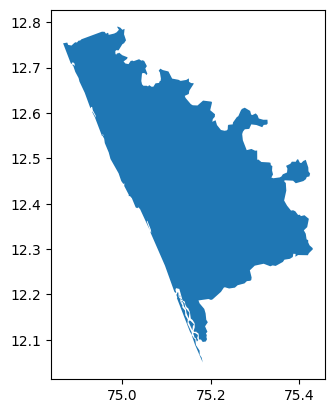

In [37]:
# plotted kasaragod district in kerala (top-most district)
kasaragod.plot()

In [38]:
## left coast 
## east - right side
## north (top)
## south (bottom) 
## center 

## drawing perfect polygons isn't possible without the right data which I currently need better sources for, 
# so will focus on making a weighted multilingual distribution map
## based on PSLI -- this is based on a 2001 census 

In [39]:
df_kasara = pd.read_csv("kasaragod_district_mapping.csv")
df_kasara

,district,language,speakers,latitude,longitude,reasoning
0,Kasaragod,Malayalam,979827,12.50,75.20,center
1,Kasaragod,Tulu,116919,12.70,75.10,north coast
2,Kasaragod,Kannada,50575,12.60,75.30,east
3,Kasaragod,Marathi,24382,12.50,75.25,inland
4,Kasaragod,Konkani,17199,12.65,75.08,north coast
5,Kasaragod,Urdu,6297,12.40,75.05,coast
6,Kasaragod,Tamil,5065,12.30,75.20,south
7,Kasaragod,Hindi,1671,12.55,75.18,scattered
8,Kasaragod,Gujarati,752,12.45,75.22,scattered
9,Kasaragod,Telugu,566,12.35,75.24,scattered


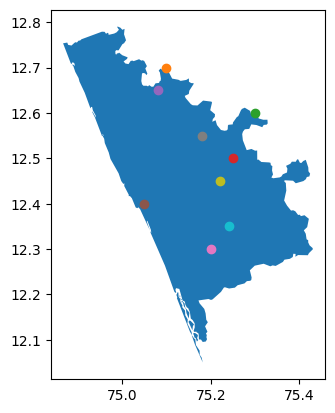

In [40]:
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
kasaragod.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_kasara.iterrows(): 
    ax.scatter(row["longitude"], row["latitude"])

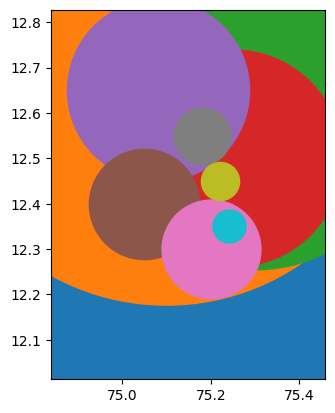

In [41]:
### gotta scale dots by size (speaker population_ 
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
kasaragod.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_kasara.iterrows(): 
    ax.scatter(row["longitude"], row["latitude"], s=row["speakers"])

In [42]:
### the above is way too big, need to scale properly 

In [43]:
## making a dictionary for colors  
### THIS TIME IT WILL BE APPLIED TO ALL DISTRICTS
color_map = {
    "Malayalam": "red",
    "Tulu": "cyan",
    "Kannada": "green", 
    "Marathi": "pink", 
    "Konkani": "yellow",
    "Urdu": "brown", 
    "Tamil": "black", 
    "Hindi": "grey", 
    "Gujarati": "orange",
    "Telugu": "purple",
    "Odiya": "darkkhaki",
    "English": "teal", 
    "Bengali": "darkgreen",
    "Nepali": "olive",
    "Others": "lightpink"

} 

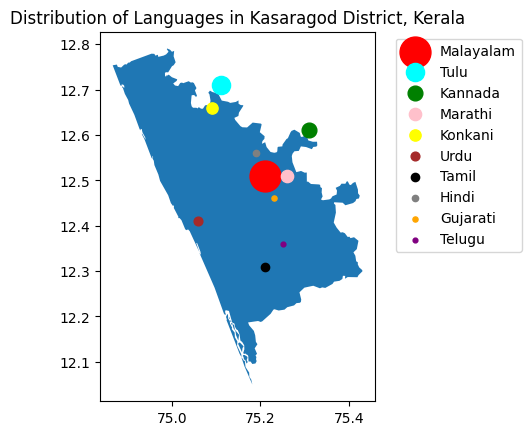

In [44]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
kasaragod.plot(ax=ax)



## using for loop to plot each language in the district 
for index, row in df_kasara.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Distribution of Languages in Kasaragod District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

In [45]:
### i think using plotly to make the labels more interactive could be useful 

In [46]:
### still using PLSI 

### Kannur District

In [47]:
Kannur = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Kannur")]
Kannur 

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
284,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07..."


<Axes: >

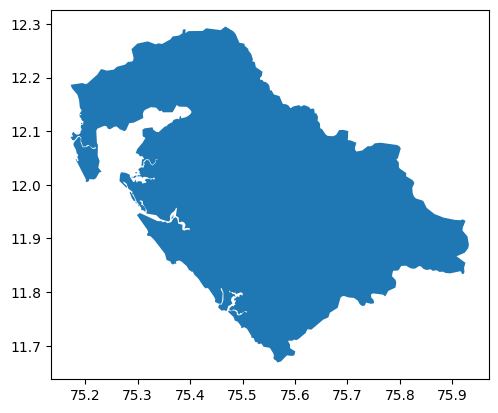

In [48]:
Kannur.plot()

In [49]:
df_kannur = pd.read_csv("kannur_district_mapping.csv")
df_kannur

,district,language,speakers,latitude,longitude,reasoning
0,Kannur,Malayalam,2383901,12.0,75.5,center
1,Kannur,Tamil,9560,11.9,75.8,NaN
2,Kannur,Gujarati,3364,11.8,75.7,NaN
3,Kannur,Kannada,2512,11.8,75.6,NaN
4,Kannur,Telugu,2333,11.7,75.5,NaN
5,Kannur,Hindi,2102,11.6,75.5,NaN
6,Kannur,Konkani,1895,11.5,75.4,NaN
7,Kannur,Marathi,768,11.4,75.7,NaN
8,Kannur,Urdu,548,11.6,75.6,NaN
9,Kannur,Odiya,534,11.7,75.4,NaN


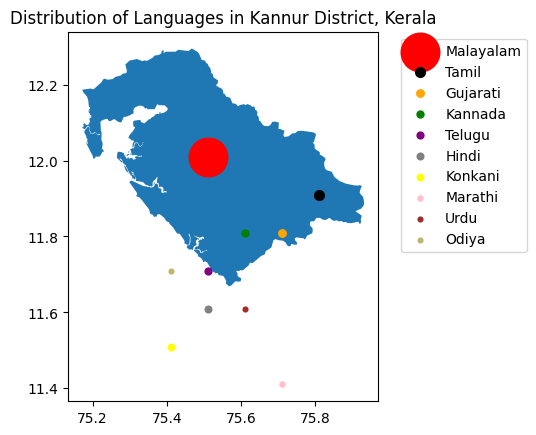

In [50]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
Kannur.plot(ax=ax)



## using for loop to plot each language in the district 
for index, row in df_kannur.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Distribution of Languages in Kannur District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Kozhikode District

In [51]:
kozhikode = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Kozhikode")]
kozhikode

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
288,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128..."


<Axes: >

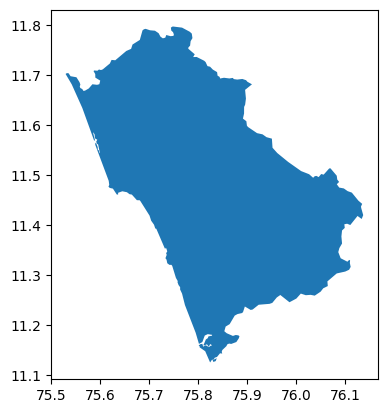

In [52]:
kozhikode.plot()

In [53]:
df_kozhikode = pd.read_csv("kozhikode_district_mapping.csv")
df_kozhikode

,district,language,speakers,latitude,longitude,reasoning
0,kozhikode,Malayalam,2852482,11.3,75.9,NaN
1,kozhikode,Tamil,13298,11.2,75.9,NaN
2,kozhikode,Gujarati,3764,11.4,75.8,NaN
3,kozhikode,Telugu,2138,11.5,75.8,NaN
4,kozhikode,Hindi,1922,11.5,75.7,NaN
5,kozhikode,Kannada,1238,11.6,75.8,NaN
6,kozhikode,Konkani,1120,11.5,76.0,NaN
7,kozhikode,Marathi,842,11.4,76.0,NaN
8,kozhikode,Urdu,623,11.6,75.7,NaN


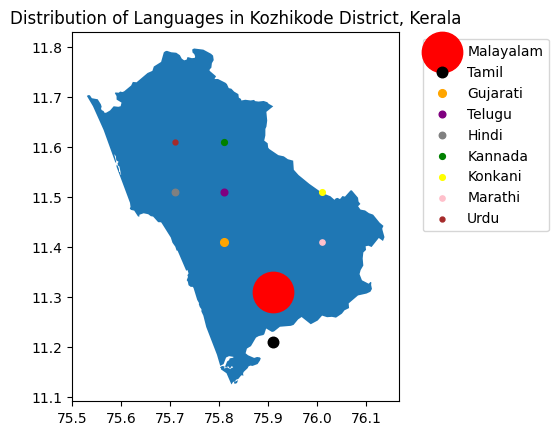

In [54]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
kozhikode.plot(ax=ax)



## using for loop to plot each language in the district 
for index, row in df_kozhikode.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Distribution of Languages in Kozhikode District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Wayanad District

In [55]:
Wayanad = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Wayanad")]
Wayanad 

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
294,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46..."


<Axes: >

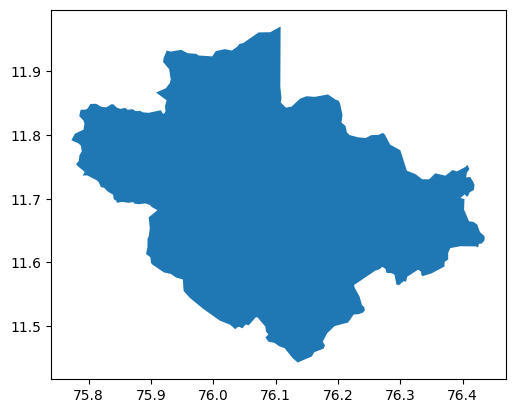

In [56]:
Wayanad.plot()

In [57]:
df_wayanad = pd.read_csv("wayanad_district_mapping.csv")
df_wayanad

,district,language,speakers,latitude,longitude,reasoning
0,Wayanad,Malayalam,754116,11.7,76.10,centroid
1,Wayanad,Tamil,10172,11.6,76.35,southeast
2,Wayanad,Kannada,9958,11.8,76.20,northeast
3,Wayanad,Telugu,1886,11.6,76.15,scattered/offset
4,Wayanad,Tulu,982,11.9,76.10,northwest
5,Wayanad,Gujarati,889,11.5,76.80,southwest
6,Wayanad,Hindi,799,11.6,76.50,southwest


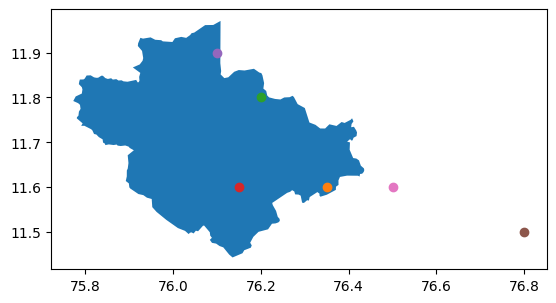

In [58]:
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
Wayanad.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_wayanad.iterrows(): 
    ax.scatter(row["longitude"], row["latitude"])

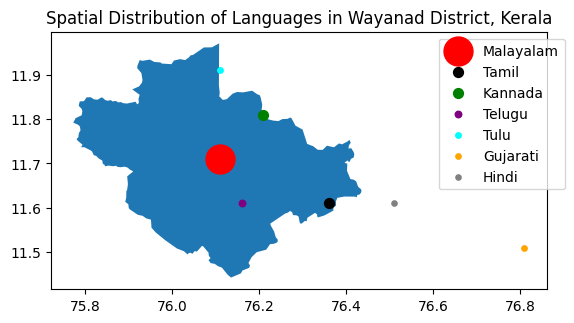

In [59]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
Wayanad.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_wayanad.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Wayanad District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Malappuram District

In [60]:
malappuram = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Malappuram")]
malappuram

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
289,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80..."


<Axes: >

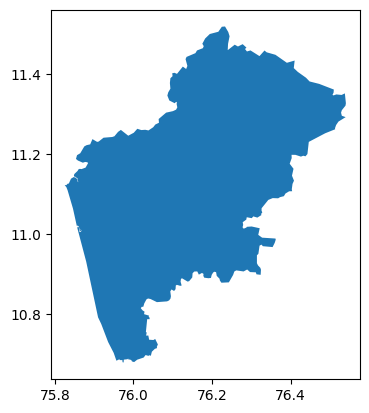

In [61]:
malappuram.plot()

In [62]:
df_malappuram = pd.read_csv("malappuram_district_mapping.csv")
df_malappuram

,district,language,speakers,latitude,longitude
0,malappuram,Malayalam,3604887,11.2,76.00
1,malappuram,Tamil,13264,11.2,76.20
2,malappuram,Telugu,2001,11.4,76.25
3,malappuram,Kannada,1276,11.2,76.00
4,malappuram,Gujarati,1059,11.0,76.10
5,malappuram,Hindi,683,11.3,76.40
6,malappuram,Marathi,591,11.4,76.20


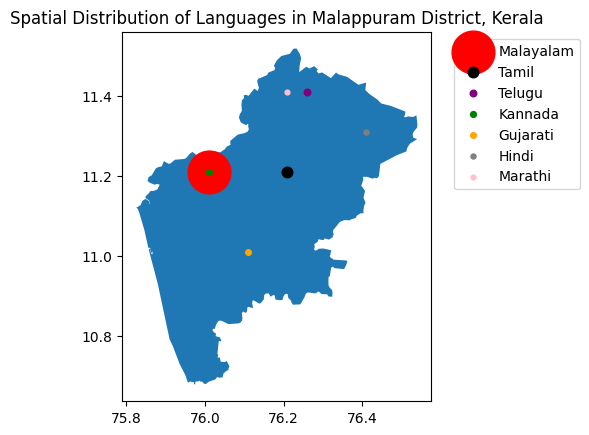

In [63]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
malappuram.plot(ax=ax)



## using for loop to plot each language in the district 
for index, row in df_malappuram.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Malappuram District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Palakkad District

In [64]:
palakkad = districts[(districts["NAME_1"] =="Kerala") & (districts["NAME_2"] == "Palakkad")]
palakkad

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
290,IND.17.10_1,IND,India,IND.17_1,Kerala,NA,Palakkad,Palghat,NA,District,District,NA,IN.KL.PL,"MULTIPOLYGON (((76.6749 10.9064, 76.6846 10.90..."


<Axes: >

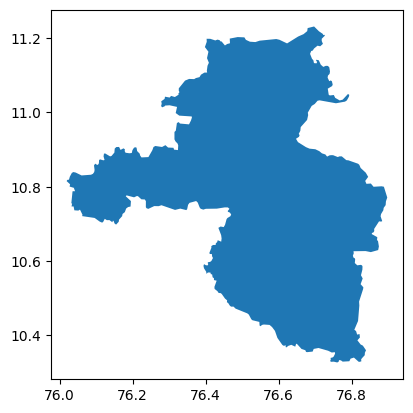

In [65]:
palakkad.plot()

In [66]:
df_palakkad = pd.read_csv("palakkad_district_mapping.csv")
df_palakkad

,district,language,speakers,latitude,longitude
0,palakkad,Malayalam,2408847,10.4,76.6
1,palakkad,Tamil,160991,10.8,76.8
2,palakkad,Telugu,21854,10.6,76.8
3,palakkad,Others,14131,10.6,76.6
4,palakkad,Kannada,6785,10.7,76.8
5,palakkad,Urdu,2098,10.8,76.1
6,palakkad,Hindi,778,11.4,76.2


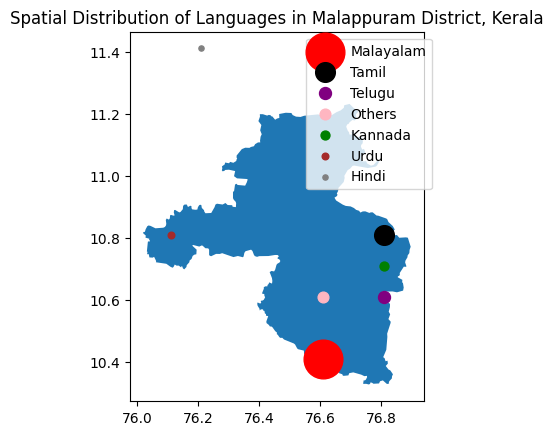

In [67]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
palakkad.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_palakkad.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Malappuram District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Thrissur District

In [68]:
thrissur = districts[(districts["NAME_1"] =="Kerala") & (districts["NAME_2"] == "Thrissur")]
thrissur

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
293,IND.17.13_1,IND,India,IND.17_1,Kerala,NA,Thrissur,Trichur,NA,District,District,NA,IN.KL.TS,"MULTIPOLYGON (((76.2509 10.1881, 76.2536 10.18..."


<Axes: >

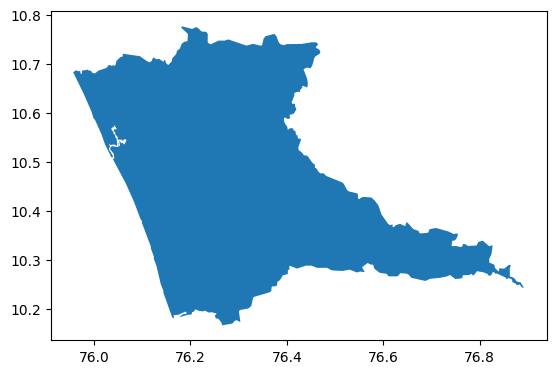

In [69]:
thrissur.plot()

In [70]:
df_thrissur = pd.read_csv("thrissur_district_mapping.csv")
df_thrissur

,district,language,speakers,latitude,longitude
0,thrissur,Malayalam,2943407,10.5,76.4
1,thrissur,Tamil,18772,10.3,76.8
2,thrissur,Telugu,3562,10.4,76.6
3,thrissur,Kannada,2767,10.6,76.4
4,thrissur,Konkani,2170,10.3,76.4
5,thrissur,Hindi,894,10.7,76.4
6,thrissur,Urdu,654,10.4,76.5
7,thrissur,Marathi,643,10.3,76.7


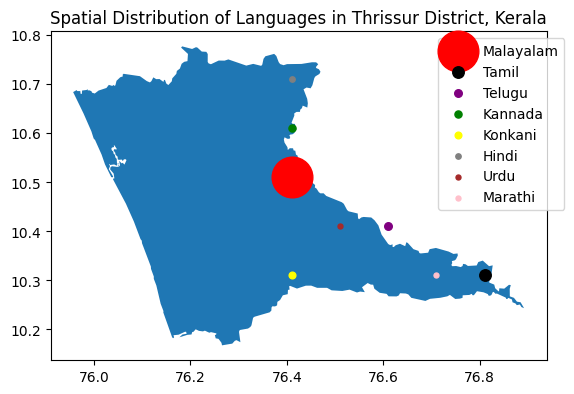

In [71]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
thrissur.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_thrissur.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Thrissur District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

In [72]:
### I want to make a multiregion map
upper_half_districts = pd.concat([kasaragod, Kannur, kozhikode, Wayanad, malappuram, palakkad, thrissur])
upper_half_districts

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
285,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194..."
284,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07..."
288,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128..."
294,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46..."
289,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80..."
290,IND.17.10_1,IND,India,IND.17_1,Kerala,NA,Palakkad,Palghat,NA,District,District,NA,IN.KL.PL,"MULTIPOLYGON (((76.6749 10.9064, 76.6846 10.90..."
293,IND.17.13_1,IND,India,IND.17_1,Kerala,NA,Thrissur,Trichur,NA,District,District,NA,IN.KL.TS,"MULTIPOLYGON (((76.2509 10.1881, 76.2536 10.18..."


In [73]:
upper_half_df = [df_kasara, df_kannur, df_kozhikode, df_wayanad, df_malappuram, df_palakkad, df_thrissur]

Text(0.5, 1.0, 'Relative Spatial Distribution of Languages in Northern Kerala (District-level)')

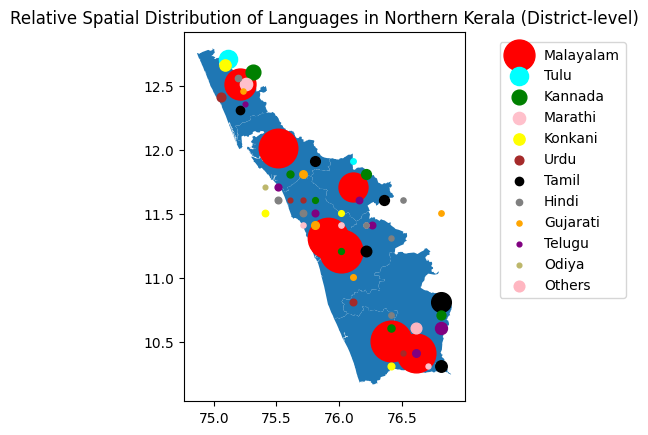

In [74]:
seen_languages = set()

fig, ax = plt.subplots()
#kerala = districts[(districts["NAME_1"] =="Kerala") & (districts["NAME_2"].isin(upper_half_districts))]
# kerala.plot()

upper_half_districts.plot(ax=ax)
# for each dataframe (df_kasara, df_kannur) 
for dataframe in upper_half_df: 
    # for each language in that dataframe's language column
    for index, row in dataframe.iterrows(): 
        
        # create the scatterplot
        lang = row["language"]
        ## checking if this is a new language 
        if lang not in seen_languages:
            seen_languages.add(lang)
            label = lang
        else: 
            label = "" 
            
        
        color = color_map[lang]
        longitude = row["longitude"]
        latitude = row["latitude"]
        speakers = row["speakers"]

        ax.scatter(longitude + .01, latitude + .01, s=np.sqrt(speakers) * .5, color=color, label=label)

ax.legend(bbox_to_anchor=(1.1, .99))
ax.set_title("Relative Spatial Distribution of Languages in Northern Kerala (District-level)", fontsize=12)

## Southern Kerala

### Ernakulam District

In [75]:
ernakulam = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Ernakulam")]
ernakulam

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
282,IND.17.2_1,IND,India,IND.17_1,Kerala,NA,Ernakulam,NA,NA,District,District,NA,IN.KL.ER,"MULTIPOLYGON (((76.3771 9.8404, 76.3749 9.8376..."


<Axes: >

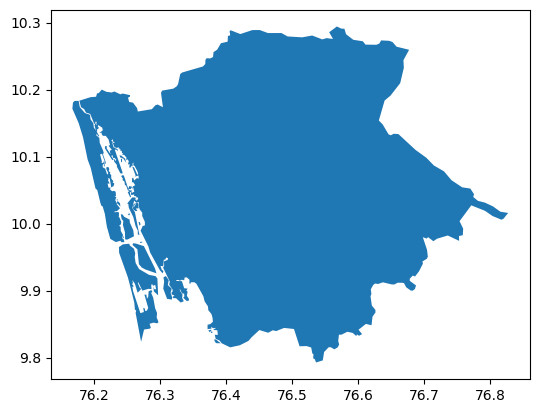

In [76]:
ernakulam.plot()

In [77]:
df_ernakulam = pd.read_csv("ernakulam_district_mapping.csv")
df_ernakulam

,district,language,speakers,latitude,longitude
0,Ernakulam,Malayalam,3006800,10.05,76.5
1,Ernakulam,Tamil,39013,10.05,76.7
2,Ernakulam,Konkani,26820,10.10,76.2
3,Ernakulam,Hindi,12276,9.90,76.4
4,Ernakulam,Telugu,3951,10.00,76.7
5,Ernakulam,Gujarati,3152,10.00,76.8
6,Ernakulam,English,2035,10.10,76.3
7,Ernakulam,Kannada,1869,10.20,76.5
8,Ernakulam,Marathi,1680,10.00,76.3
9,Ernakulam,Urdu,1271,10.10,76.6


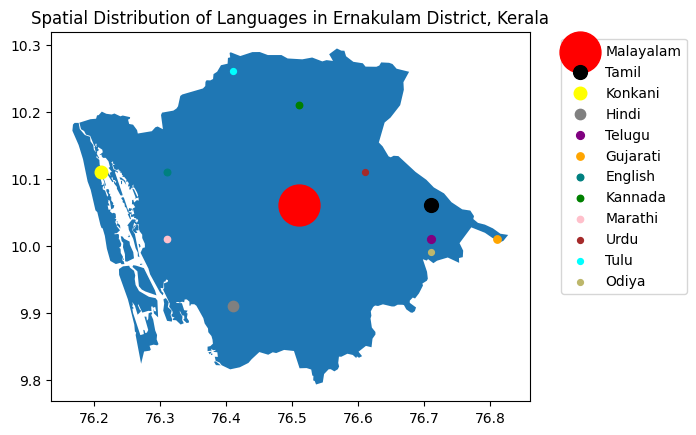

In [78]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
ernakulam.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_ernakulam.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Ernakulam District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Idukki District

In [79]:
idukki = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Idukki")]
idukki

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
283,IND.17.3_1,IND,India,IND.17_1,Kerala,NA,Idukki,Idikki,NA,District,District,NA,IN.KL.ID,"MULTIPOLYGON (((77.1991 10.0707, 77.2044 10.06..."


idukki.plot()

In [80]:
df_idukki = pd.read_csv("idukki_district_mapping.csv")
df_idukki

,district,language,speakers,latitude,longitude
0,Idukki,Malayalam,900907,9.9,77.00
1,Idukki,Tamil,221734,9.8,77.25
2,Idukki,Telugu,2357,10.1,77.20
3,Idukki,Kannada,2245,10.0,77.20


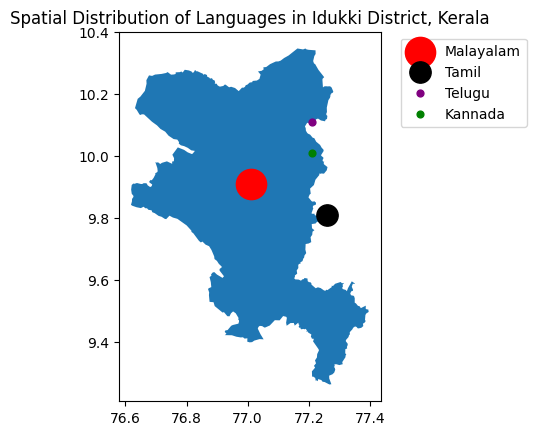

In [81]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
idukki.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_idukki.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Idukki District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Kottayam District


In [82]:
kottayam = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Kottayam")]
kottayam

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
287,IND.17.7_1,IND,India,IND.17_1,Kerala,NA,Kottayam,NA,NA,District,District,NA,IN.KL.KT,"MULTIPOLYGON (((76.4954 9.4086, 76.4969 9.4105..."


<Axes: >

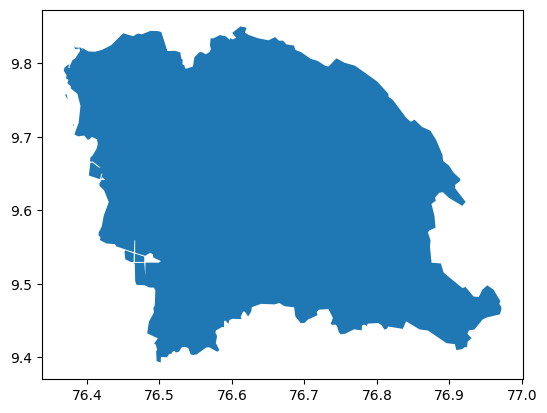

In [83]:
kottayam.plot()

In [84]:
df_kottayam = pd.read_csv("kottayam_district_mapping.csv")
df_kottayam

,district,language,speakers,latitude,longitude
0,Kottayam,Malayalam,19933792,9.60,76.70
1,Kottayam,Tamil,13940,9.70,76.80
2,Kottayam,Konkani,1232,9.60,76.40
3,Kottayam,Telugu,1142,9.60,76.80
4,Kottayam,Gujarati,1041,9.65,76.75
5,Kottayam,Hindi,653,9.72,76.75


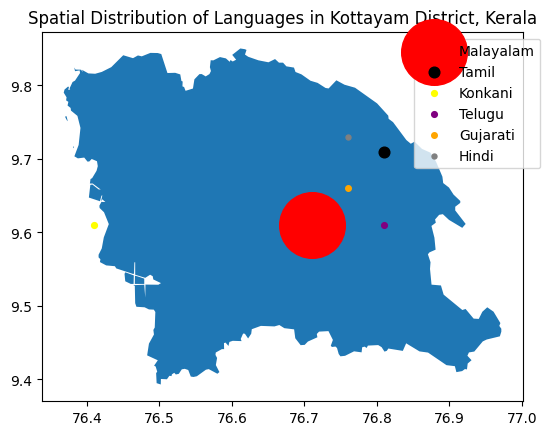

In [85]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
kottayam.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_kottayam.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Kottayam District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Alappuzha District

In [86]:
alappuzha = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Alappuzha")]
alappuzha

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
281,IND.17.1_1,IND,India,IND.17_1,Kerala,NA,Alappuzha,Alleppey,NA,District,District,NA,IN.KL.AL,"MULTIPOLYGON (((76.6292 9.2071, 76.6296 9.204,..."


<Axes: >

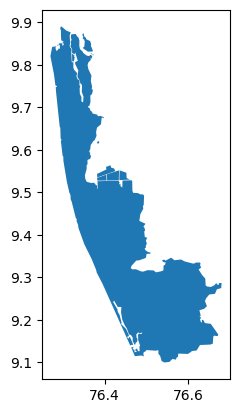

In [87]:
alappuzha.plot()

In [88]:
df_alappuzha = pd.read_csv("alappuzha_district_mapping.csv")
df_alappuzha

,district,language,speakers,latitude,longitude
0,Alappuzha,Malayalam,2089802,9.4,76.4
1,Alappuzha,Konkani,7918,9.2,76.5
2,Alappuzha,Tamil,7202,9.2,76.6
3,Alappuzha,Gujarati,999,9.3,76.6
4,Alappuzha,Telugu,801,9.7,76.3
5,Alappuzha,Hindi,570,9.8,76.3


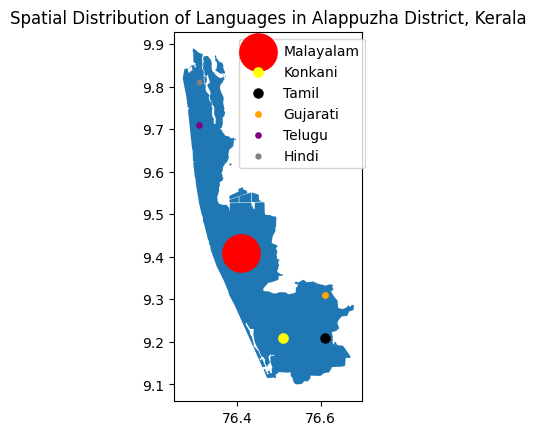

In [89]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
alappuzha.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_alappuzha.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Alappuzha District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Pathanamthitta District

In [90]:
pathanamthitta = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Pathanamthitta")]
pathanamthitta 

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
291,IND.17.11_1,IND,India,IND.17_1,Kerala,NA,Pathanamthitta,NA,NA,District,District,NA,IN.KL.PT,"MULTIPOLYGON (((76.637 9.2257, 76.6442 9.2321,..."


<Axes: >

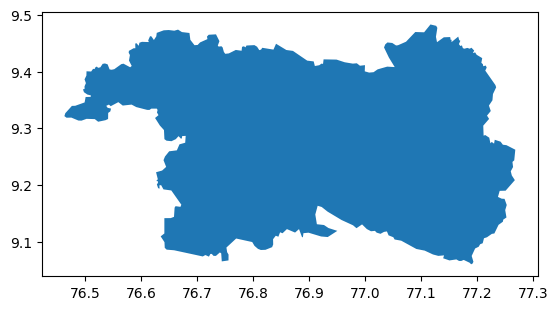

In [91]:
pathanamthitta.plot()

In [92]:
df_pathanamthitta = pd.read_csv("pathanamthitta_district_mapping.csv")
df_pathanamthitta 

,district,language,speakers,latitude,longitude
0,Pathanamthitta,Malayalam,1221743,9.30,76.95
1,Pathanamthitta,Tamil,10032,9.30,77.10
2,Pathanamthitta,Gujarati,495,9.15,76.70


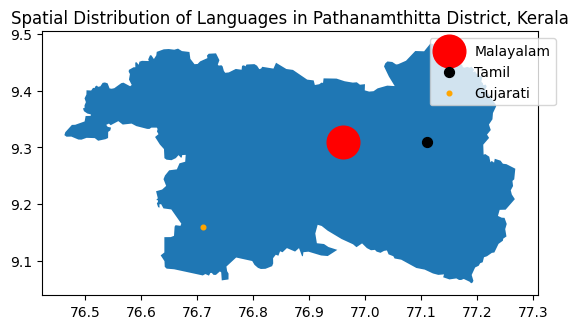

In [93]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
pathanamthitta.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_pathanamthitta.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Pathanamthitta District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

### Kollam District

In [94]:
kollam = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Kollam")]
kollam 

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
286,IND.17.6_1,IND,India,IND.17_1,Kerala,NA,Kollam,Quilon,NA,District,District,NA,IN.KL.KL,"MULTIPOLYGON (((76.7019 9.0769, 76.7096 9.0743..."


<Axes: >

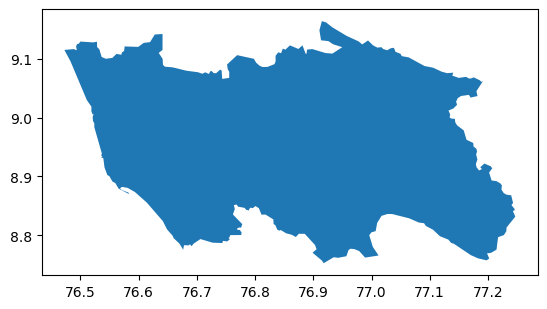

In [95]:
kollam.plot()

In [96]:
df_kollam = pd.read_csv("kollam_district_mapping.csv")
df_kollam

,district,language,speakers,latitude,longitude
0,Kollam,Malayalam,2556065,8.95,76.9
1,Kollam,Tamil,22837,9.00,77.1
2,Kollam,Telugu,2004,8.90,77.1
3,Kollam,Konkani,1053,9.05,76.5
4,Kollam,Hindi,511,8.90,76.7
5,Kollam,Bengali,501,9.00,77.0


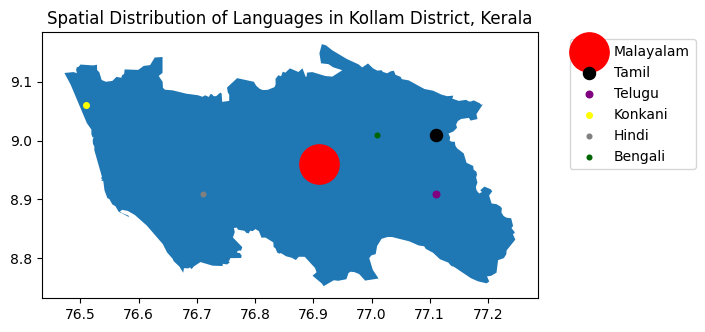

In [97]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
kollam.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_kollam.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Kollam District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

## Thiruvanathapuram

In [98]:
thiruvananthapuram = districts[(districts["NAME_1"] == "Kerala") & (districts["NAME_2"]=="Thiruvananthapuram")]
thiruvananthapuram 

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
292,IND.17.12_1,IND,India,IND.17_1,Kerala,NA,Thiruvananthapuram,Trivandrum,NA,District,District,NA,IN.KL.TV,"MULTIPOLYGON (((77.2279 8.6031, 77.2284 8.5978..."


<Axes: >

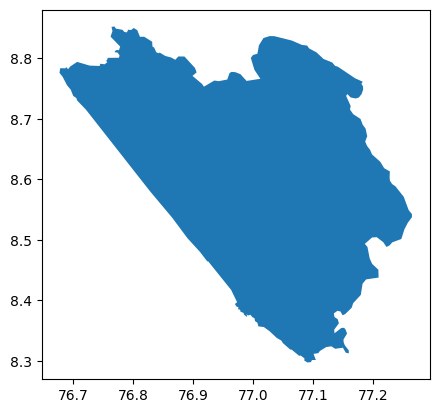

In [99]:
thiruvananthapuram.plot()

In [100]:
df_thiruvananthapuram = pd.read_csv("thiruvananthapuram_district_mapping.csv")
df_thiruvananthapuram

,district,language,speakers,latitude,longitude
0,Thiruvananthapuram,Malayalam,31671111,8.55,77.00
1,Thiruvananthapuram,Tamil,51091,8.70,77.15
2,Thiruvananthapuram,Telugu,3714,8.60,77.10
3,Thiruvananthapuram,Hindi,2931,8.50,77.10
4,Thiruvananthapuram,Tulu,1513,8.70,76.80
5,Thiruvananthapuram,Konkani,1129,8.50,77.20
6,Thiruvananthapuram,Nepali,1129,8.50,76.90
7,Thiruvananthapuram,Kannada,1089,8.40,77.10
8,Thiruvananthapuram,Urdu,981,8.50,76.90
9,Thiruvananthapuram,Marathi,880,8.40,77.00


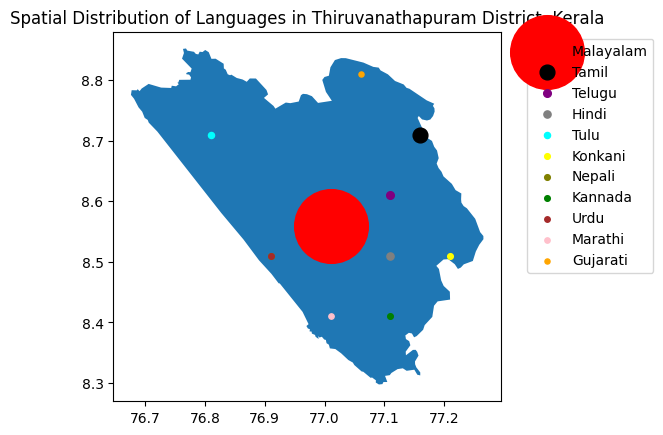

In [101]:
### gotta scale dots by size (speaker population) -- possibly non-linearly
fig, ax = plt.subplots()

## taking the geodataframe and putting it on the axes
thiruvananthapuram.plot(ax=ax)


## using for loop to plot each language in the district 
for index, row in df_thiruvananthapuram.iterrows(): 
    lang = row["language"]
    color = color_map[lang]
    ax.scatter(row["longitude"] + .01, row["latitude"] +.01, s=np.sqrt(row["speakers"])  * .5, color=color, label=lang) 

ax.set_title("Spatial Distribution of Languages in Thiruvanathapuram District, Kerala", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1))

In [102]:
### for lower half districts, a multiregion map
lower_half_districts = pd.concat([ernakulam, idukki, kottayam, alappuzha, pathanamthitta, kollam, thiruvananthapuram])
lower_half_districts

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
282,IND.17.2_1,IND,India,IND.17_1,Kerala,NA,Ernakulam,NA,NA,District,District,NA,IN.KL.ER,"MULTIPOLYGON (((76.3771 9.8404, 76.3749 9.8376..."
283,IND.17.3_1,IND,India,IND.17_1,Kerala,NA,Idukki,Idikki,NA,District,District,NA,IN.KL.ID,"MULTIPOLYGON (((77.1991 10.0707, 77.2044 10.06..."
287,IND.17.7_1,IND,India,IND.17_1,Kerala,NA,Kottayam,NA,NA,District,District,NA,IN.KL.KT,"MULTIPOLYGON (((76.4954 9.4086, 76.4969 9.4105..."
281,IND.17.1_1,IND,India,IND.17_1,Kerala,NA,Alappuzha,Alleppey,NA,District,District,NA,IN.KL.AL,"MULTIPOLYGON (((76.6292 9.2071, 76.6296 9.204,..."
291,IND.17.11_1,IND,India,IND.17_1,Kerala,NA,Pathanamthitta,NA,NA,District,District,NA,IN.KL.PT,"MULTIPOLYGON (((76.637 9.2257, 76.6442 9.2321,..."
286,IND.17.6_1,IND,India,IND.17_1,Kerala,NA,Kollam,Quilon,NA,District,District,NA,IN.KL.KL,"MULTIPOLYGON (((76.7019 9.0769, 76.7096 9.0743..."
292,IND.17.12_1,IND,India,IND.17_1,Kerala,NA,Thiruvananthapuram,Trivandrum,NA,District,District,NA,IN.KL.TV,"MULTIPOLYGON (((77.2279 8.6031, 77.2284 8.5978..."


In [103]:
lower_half_df = [df_ernakulam, df_idukki, df_kottayam, df_alappuzha, df_pathanamthitta, df_kollam, df_thiruvananthapuram]

Text(0.5, 1.0, 'Relative Spatial Distribution of Languages in Southern Kerala (District-level) based on PLSI')

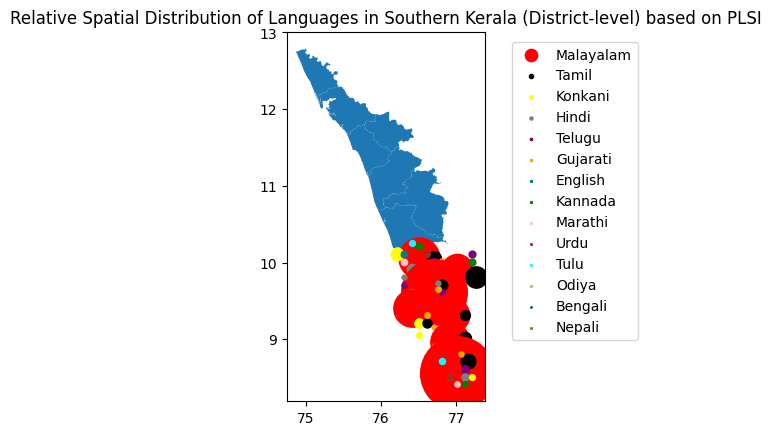

In [104]:
seen_languages = set()

fig, ax = plt.subplots()
#kerala = districts[(districts["NAME_1"] =="Kerala") & (districts["NAME_2"].isin(upper_half_districts))]
# kerala.plot()

upper_half_districts.plot(ax=ax)
# for each dataframe (df_kasara, df_kannur) 
for dataframe in lower_half_df: 
    # for each language in that dataframe's language column
    for index, row in dataframe.iterrows(): 
        
        # create the scatterplot
        lang = row["language"]
        ## checking if this is a new language 
        if lang not in seen_languages:
            seen_languages.add(lang)
            label = lang
        else: 
            label = "" 
            
        
        color = color_map[lang]
        longitude = row["longitude"]
        latitude = row["latitude"]
        speakers = row["speakers"]

        ax.scatter(longitude + .01, latitude + .01, s=np.sqrt(speakers) * .5, color=color, label=label)

ax.legend(bbox_to_anchor=(1.1, .99), markerscale=.3)
ax.set_title("Relative Spatial Distribution of Languages in Southern Kerala (District-level) based on PLSI", fontsize=12)

### Full Map of Kerala Language Distribution

In [105]:
all_districts = pd.concat([kasaragod, Kannur, kozhikode, Wayanad, malappuram, palakkad, thrissur, ernakulam, idukki, kottayam, alappuzha, pathanamthitta, kollam, thiruvananthapuram])
all_districts

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
285,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194..."
284,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07..."
288,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128..."
294,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46..."
289,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80..."
290,IND.17.10_1,IND,India,IND.17_1,Kerala,NA,Palakkad,Palghat,NA,District,District,NA,IN.KL.PL,"MULTIPOLYGON (((76.6749 10.9064, 76.6846 10.90..."
293,IND.17.13_1,IND,India,IND.17_1,Kerala,NA,Thrissur,Trichur,NA,District,District,NA,IN.KL.TS,"MULTIPOLYGON (((76.2509 10.1881, 76.2536 10.18..."
282,IND.17.2_1,IND,India,IND.17_1,Kerala,NA,Ernakulam,NA,NA,District,District,NA,IN.KL.ER,"MULTIPOLYGON (((76.3771 9.8404, 76.3749 9.8376..."
283,IND.17.3_1,IND,India,IND.17_1,Kerala,NA,Idukki,Idikki,NA,District,District,NA,IN.KL.ID,"MULTIPOLYGON (((77.1991 10.0707, 77.2044 10.06..."
287,IND.17.7_1,IND,India,IND.17_1,Kerala,NA,Kottayam,NA,NA,District,District,NA,IN.KL.KT,"MULTIPOLYGON (((76.4954 9.4086, 76.4969 9.4105..."


In [106]:
all_language_dfs = upper_half_df + lower_half_df
all_language_dfs

[   district    language  speakers  latitude  longitude    reasoning
 0  Kasaragod  Malayalam    979827     12.50      75.20       center
 1  Kasaragod       Tulu    116919     12.70      75.10  north coast
 2  Kasaragod    Kannada     50575     12.60      75.30         east
 3  Kasaragod    Marathi     24382     12.50      75.25       inland
 4  Kasaragod    Konkani     17199     12.65      75.08  north coast
 5  Kasaragod       Urdu      6297     12.40      75.05        coast
 6  Kasaragod      Tamil      5065     12.30      75.20        south
 7  Kasaragod      Hindi      1671     12.55      75.18    scattered
 8  Kasaragod   Gujarati       752     12.45      75.22    scattered
 9  Kasaragod     Telugu       566     12.35      75.24    scattered,
   district    language  speakers  latitude  longitude reasoning
 0    Kannur  Malayalam   2383901      12.0       75.5    center
 1    Kannur      Tamil      9560      11.9       75.8       NaN
 2    Kannur   Gujarati      3364      11.8  

Text(0.5, 1.0, 'Relative Spatial and Population Distribution of Languages in Kerala (District-level) based on PLSI')

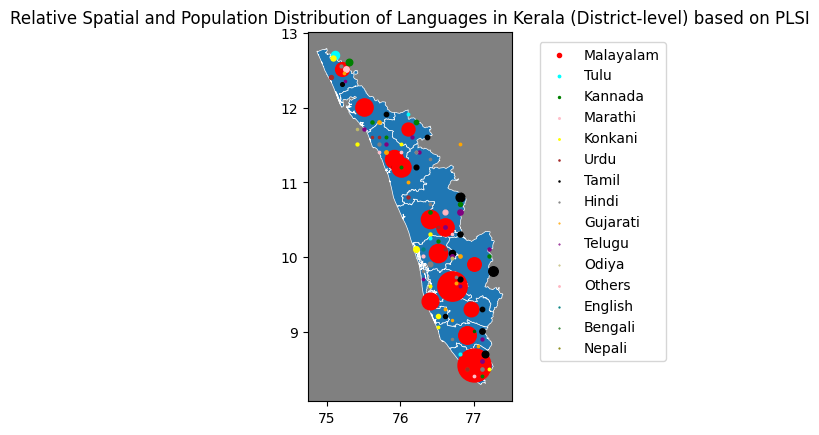

In [107]:
seen_languages = set()

fig, ax = plt.subplots()
#kerala = districts[(districts["NAME_1"] =="Kerala") & (districts["NAME_2"].isin(upper_half_districts))]
# kerala.plot()

all_districts.plot(ax=ax, linewidth=.5, edgecolor="white")
# for each dataframe (df_kasara, df_kannur) 
for dataframe in all_language_dfs: 
    # for each language in that dataframe's language column
    for index, row in dataframe.iterrows(): 
        
        # create the scatterplot
        lang = row["language"]
        ## checking if this is a new language 
        if lang not in seen_languages:
            seen_languages.add(lang)
            label = lang
        else: 
            label = "" 
            
        
        color = color_map[lang]
        longitude = row["longitude"]
        latitude = row["latitude"]
        speakers = row["speakers"]

        ax.scatter(longitude + .01, latitude + .01, s=np.sqrt(speakers) * .1, color=color, label=label)

ax.legend(bbox_to_anchor=(1.1, .99), markerscale=.3)
ax.set_facecolor('gray')
ax.set_title("Relative Spatial and Population Distribution of Languages in Kerala (District-level) based on PLSI", fontsize=12)

#### I will now show a choropleth map of Malayalam language distribution dominance percentages in Kerala. 

In [108]:
mal_dist_kerala_plsi_df = pd.read_csv("malayalam_perc_district_mapping.csv")
mal_dist_kerala_plsi_df

,district,language,speakers
0,Kasaragod,Malayalam,979827
1,Kannur,Malayalam,2383901
2,Wayanad,Malayalam,754116
3,Kozhikode,Malayalam,2852482
4,Malappuram,Malayalam,3604887
5,Palakkad,Malayalam,2408847
6,Thrissur,Malayalam,2943407
7,Ernakulam,Malayalam,3006860
8,Idukki,Malayalam,900907
9,Kottayam,Malayalam,1933792


<Axes: >

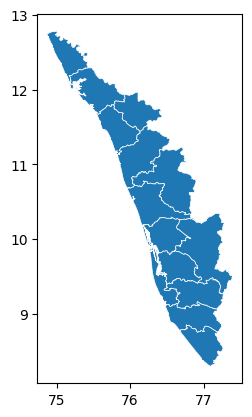

In [109]:
all_districts.plot(linewidth=.5, edgecolor="white")

In [110]:
all_districts

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
285,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194..."
284,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07..."
288,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128..."
294,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46..."
289,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80..."
290,IND.17.10_1,IND,India,IND.17_1,Kerala,NA,Palakkad,Palghat,NA,District,District,NA,IN.KL.PL,"MULTIPOLYGON (((76.6749 10.9064, 76.6846 10.90..."
293,IND.17.13_1,IND,India,IND.17_1,Kerala,NA,Thrissur,Trichur,NA,District,District,NA,IN.KL.TS,"MULTIPOLYGON (((76.2509 10.1881, 76.2536 10.18..."
282,IND.17.2_1,IND,India,IND.17_1,Kerala,NA,Ernakulam,NA,NA,District,District,NA,IN.KL.ER,"MULTIPOLYGON (((76.3771 9.8404, 76.3749 9.8376..."
283,IND.17.3_1,IND,India,IND.17_1,Kerala,NA,Idukki,Idikki,NA,District,District,NA,IN.KL.ID,"MULTIPOLYGON (((77.1991 10.0707, 77.2044 10.06..."
287,IND.17.7_1,IND,India,IND.17_1,Kerala,NA,Kottayam,NA,NA,District,District,NA,IN.KL.KT,"MULTIPOLYGON (((76.4954 9.4086, 76.4969 9.4105..."


In [111]:
all_districts["NAME_2"]

285             Kasaragod
284                Kannur
288             Kozhikode
294               Wayanad
289            Malappuram
290              Palakkad
293              Thrissur
282             Ernakulam
283                Idukki
287              Kottayam
281             Alappuzha
291        Pathanamthitta
286                Kollam
292    Thiruvananthapuram
Name: NAME_2, dtype: str

In [112]:
mal_dist_kerala_plsi_df["district"]

0              Kasaragod
1                 Kannur
2                Wayanad
3              Kozhikode
4             Malappuram
5               Palakkad
6               Thrissur
7              Ernakulam
8                 Idukki
9               Kottayam
10             Alappuzha
11        Pathanamthitta
12                Kollam
13    Thiruvananthapuram
Name: district, dtype: str

In [113]:
merged_malayalam = all_districts.merge(mal_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_malayalam.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Malayalam,979827
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Malayalam,2383901
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Malayalam,2852482
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Malayalam,754116
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Malayalam,3604887


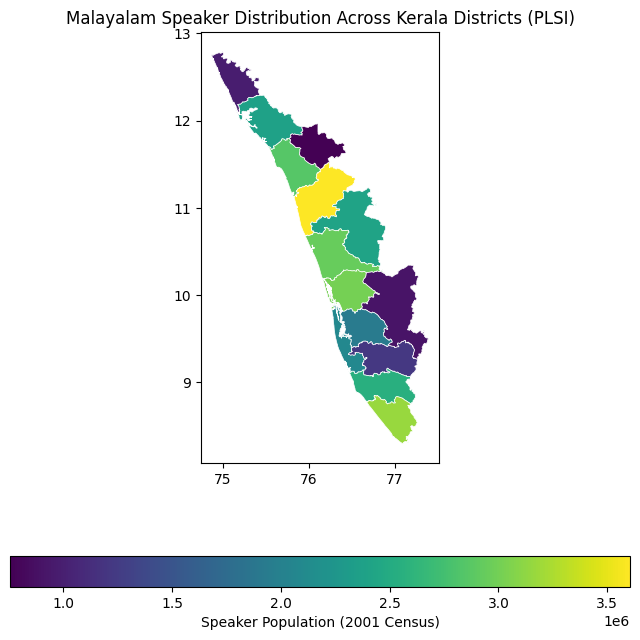

In [114]:
fig, ax = plt.subplots(figsize=(8,8))

merged_malayalam.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Malayalam Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

### Tulu 

In [115]:
tulu_dist_kerala_plsi_df = pd.read_csv("tulu_perc_district_mapping.csv")
tulu_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Tulu,116919,NaN
1,Kannur,Tulu,0,NaN
2,Wayanad,Tulu,982,NaN
3,Kozhikode,Tulu,0,NaN
4,Malappuram,Tulu,0,NaN
5,Palakkad,Tulu,0,NaN
6,Thrissur,Tulu,0,NaN
7,Ernakulam,Tulu,1271,NaN
8,Idukki,Tulu,0,NaN
9,Kottayam,Tulu,0,NaN


In [116]:
merged_tulu = all_districts.merge(tulu_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_tulu.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Tulu,116919,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Tulu,0,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Tulu,0,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Tulu,982,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Tulu,0,NaN


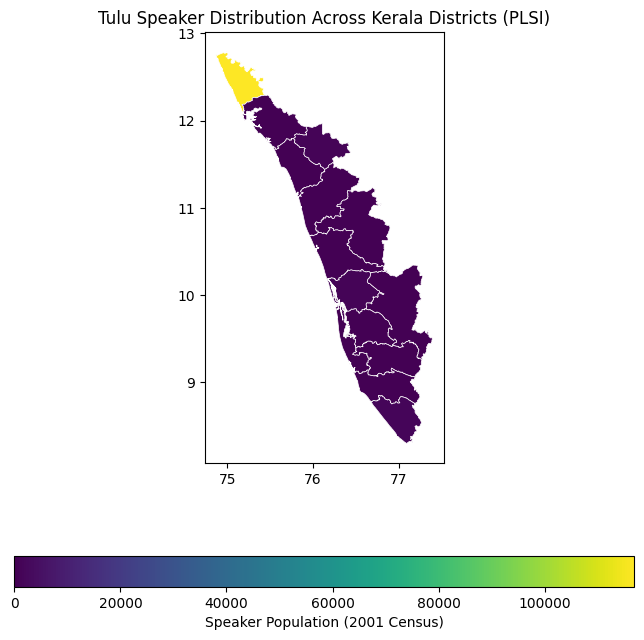

In [117]:
fig, ax = plt.subplots(figsize=(8,8))

merged_tulu.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Tulu Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

## Kannada

In [118]:
kannada_dist_kerala_plsi_df = pd.read_csv("kannada_perc_district_mapping_2001_plsi.csv")
kannada_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Kannada,50575,NaN
1,Kannur,Kannada,2512,NaN
2,Wayanad,Kannada,9948,NaN
3,Kozhikode,Kannada,1238,NaN
4,Malappuram,Kannada,1276,NaN
5,Palakkad,Kannada,6785,NaN
6,Thrissur,Kannada,2767,NaN
7,Ernakulam,Kannada,1869,NaN
8,Idukki,Kannada,2245,NaN
9,Kottayam,Kannada,0,NaN


In [119]:
merged_kannada = all_districts.merge(kannada_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_kannada.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Kannada,50575,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Kannada,2512,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Kannada,1238,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Kannada,9948,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Kannada,1276,NaN


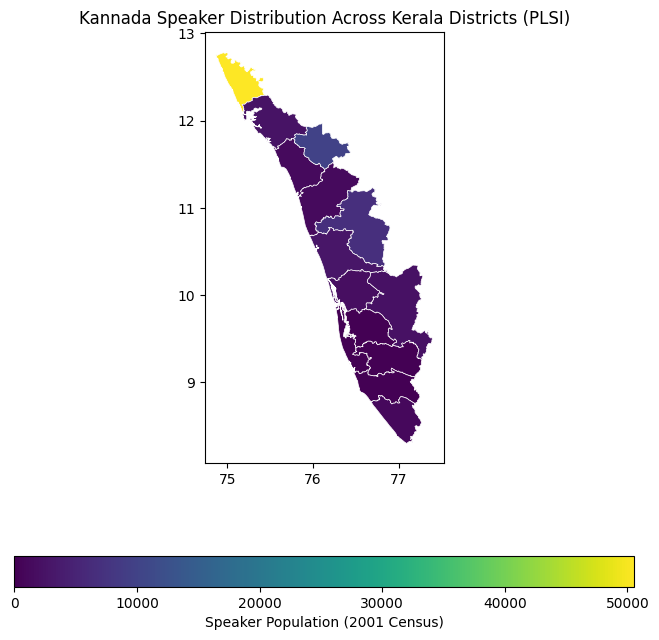

In [120]:
fig, ax = plt.subplots(figsize=(8,8))

merged_kannada.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Kannada Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Marathi

In [121]:
marathi_dist_kerala_plsi_df = pd.read_csv("marathi_perc_district_mapping.csv")
marathi_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Marathi,24382,NaN
1,Kannur,Marathi,768,NaN
2,Wayanad,Marathi,0,NaN
3,Kozhikode,Marathi,842,NaN
4,Malappuram,Marathi,591,NaN
5,Palakkad,Marathi,0,NaN
6,Thrissur,Marathi,643,NaN
7,Ernakulam,Marathi,1680,NaN
8,Idukki,Marathi,0,NaN
9,Kottayam,Marathi,0,NaN


In [122]:
merged_marathi = all_districts.merge(marathi_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_marathi.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Marathi,24382,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Marathi,768,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Marathi,842,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Marathi,0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Marathi,591,NaN


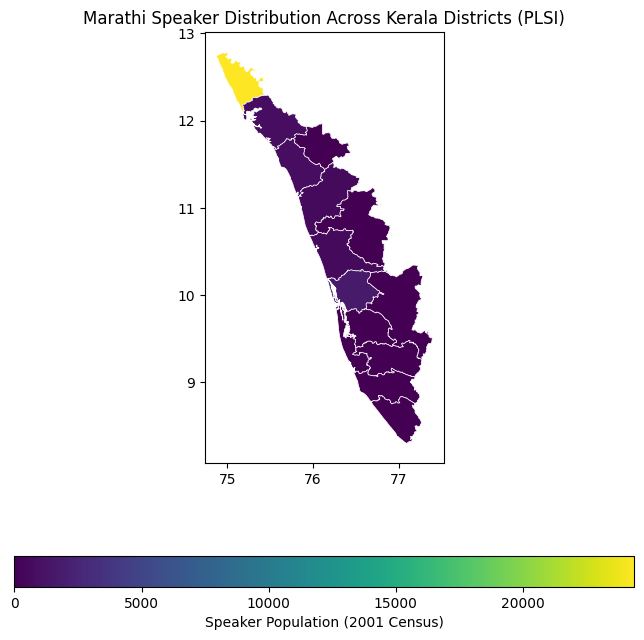

In [123]:
fig, ax = plt.subplots(figsize=(8,8))

merged_marathi.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Marathi Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Konkani

In [124]:
konkani_dist_kerala_plsi_df = pd.read_csv("konkani_perc_district_mapping.csv")
konkani_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Konkani,17199,NaN
1,Kannur,Konkani,1895,NaN
2,Wayanad,Konkani,0,NaN
3,Kozhikode,Konkani,1120,NaN
4,Malappuram,Konkani,0,NaN
5,Palakkad,Konkani,0,NaN
6,Thrissur,Konkani,2170,NaN
7,Ernakulam,Konkani,26820,NaN
8,Idukki,Konkani,0,NaN
9,Kottayam,Konkani,1232,NaN


In [125]:
merged_konkani = all_districts.merge(konkani_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_konkani.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Konkani,17199,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Konkani,1895,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Konkani,1120,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Konkani,0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Konkani,0,NaN


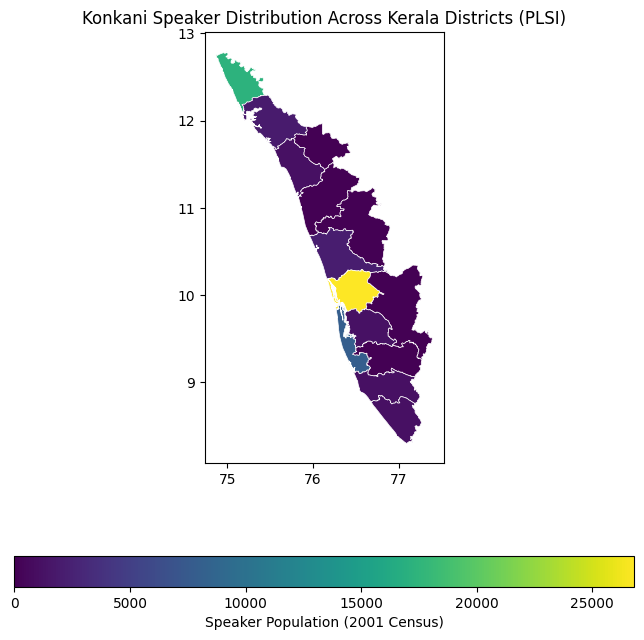

In [126]:
fig, ax = plt.subplots(figsize=(8,8))

merged_konkani.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Konkani Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Urdu 

In [127]:
urdu_dist_kerala_plsi_df = pd.read_csv("urdu_perc_district_mapping_2002_plsi.csv")
urdu_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Urdu,6297,NaN
1,Kannur,Urdu,548,NaN
2,Wayanad,Urdu,0,NaN
3,Kozhikode,Urdu,623,NaN
4,Malappuram,Urdu,0,NaN
5,Palakkad,Urdu,2098,NaN
6,Thrissur,Urdu,654,NaN
7,Ernakulam,Urdu,1271,NaN
8,Idukki,Urdu,0,NaN
9,Kottayam,Urdu,0,NaN


In [128]:
merged_urdu = all_districts.merge(urdu_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_urdu.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Urdu,6297,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Urdu,548,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Urdu,623,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Urdu,0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Urdu,0,NaN


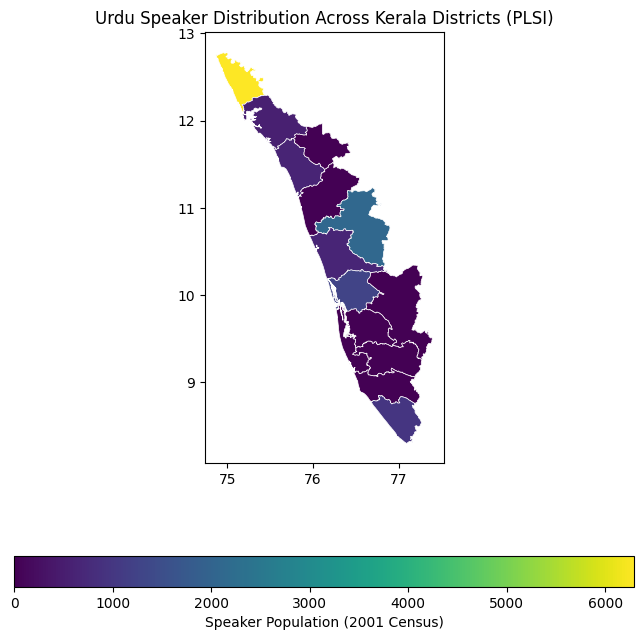

In [129]:
fig, ax = plt.subplots(figsize=(8,8))

merged_urdu.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Urdu Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Tamil

In [130]:
tamil_dist_kerala_plsi_df = pd.read_csv("tamil_perc_district_mapping_2001_plsi.csv")
tamil_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Tamil,5065,NaN
1,Kannur,Tamil,9560,NaN
2,Wayanad,Tamil,10172,NaN
3,Kozhikode,Tamil,13298,NaN
4,Malappuram,Tamil,13264,NaN
5,Palakkad,Tamil,160991,NaN
6,Thrissur,Tamil,18772,NaN
7,Ernakulam,Tamil,39013,NaN
8,Idukki,Tamil,221734,NaN
9,Kottayam,Tamil,13940,NaN


In [131]:
merged_tamil = all_districts.merge(tamil_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_tamil.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Tamil,5065,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Tamil,9560,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Tamil,13298,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Tamil,10172,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Tamil,13264,NaN


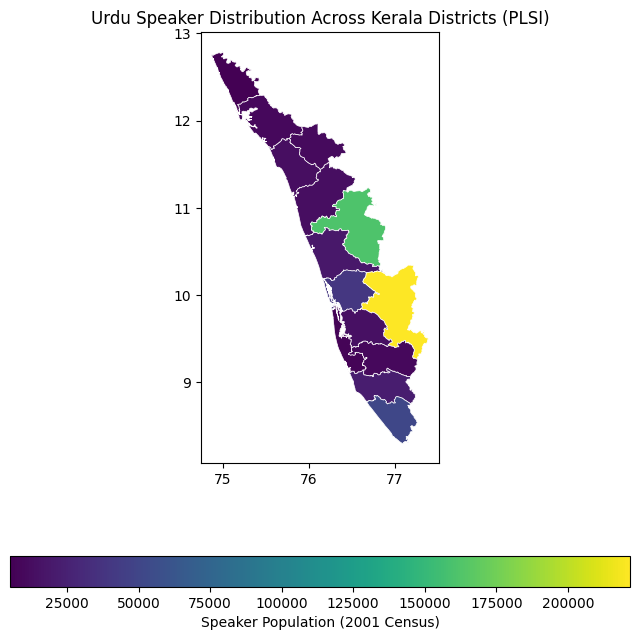

In [132]:
fig, ax = plt.subplots(figsize=(8,8))

merged_tamil.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Urdu Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Hindi 

In [133]:
hindi_dist_kerala_plsi_df = pd.read_csv("hindi_perc_district_mapping_2001_plsi.csv")
hindi_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Hindi,1671,NaN
1,Kannur,Hindi,2102,NaN
2,Wayanad,Hindi,799,NaN
3,Kozhikode,Hindi,1922,NaN
4,Malappuram,Hindi,683,NaN
5,Palakkad,Hindi,778,NaN
6,Thrissur,Hindi,894,NaN
7,Ernakulam,Hindi,12276,NaN
8,Idukki,Hindi,0,NaN
9,Kottayam,Hindi,653,NaN


In [134]:
merged_hindi = all_districts.merge(hindi_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_hindi.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Hindi,1671,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Hindi,2102,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Hindi,1922,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Hindi,799,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Hindi,683,NaN


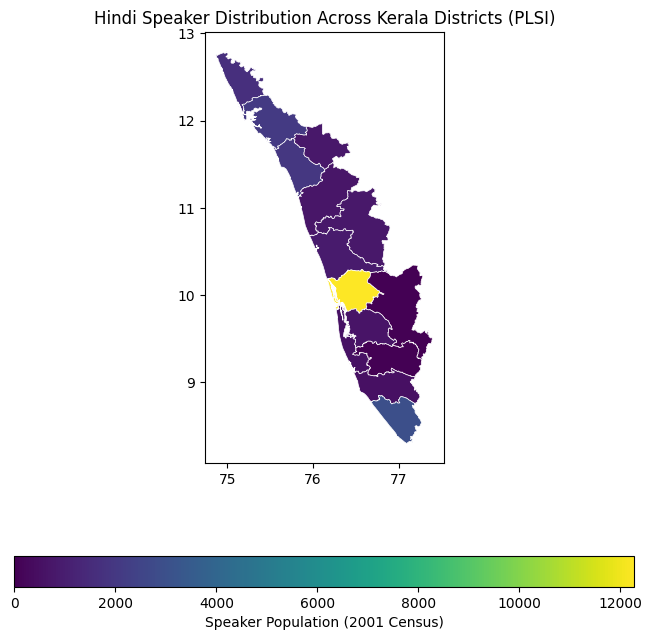

In [135]:
fig, ax = plt.subplots(figsize=(8,8))

merged_hindi.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Hindi Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Gujarati

In [136]:
gujarati_dist_kerala_plsi_df = pd.read_csv("gujarati_perc_district_mapping_2001_plsi.csv")
gujarati_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Gujarati,752,NaN
1,Kannur,Gujarati,3364,NaN
2,Wayanad,Gujarati,889,NaN
3,Kozhikode,Gujarati,3764,NaN
4,Malappuram,Gujarati,1059,NaN
5,Palakkad,Gujarati,0,NaN
6,Thrissur,Gujarati,0,NaN
7,Ernakulam,Gujarati,3152,NaN
8,Idukki,Gujarati,0,NaN
9,Kottayam,Gujarati,1041,NaN


In [137]:
merged_gujarati = all_districts.merge(gujarati_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_gujarati.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Gujarati,752,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Gujarati,3364,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Gujarati,3764,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Gujarati,889,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Gujarati,1059,NaN


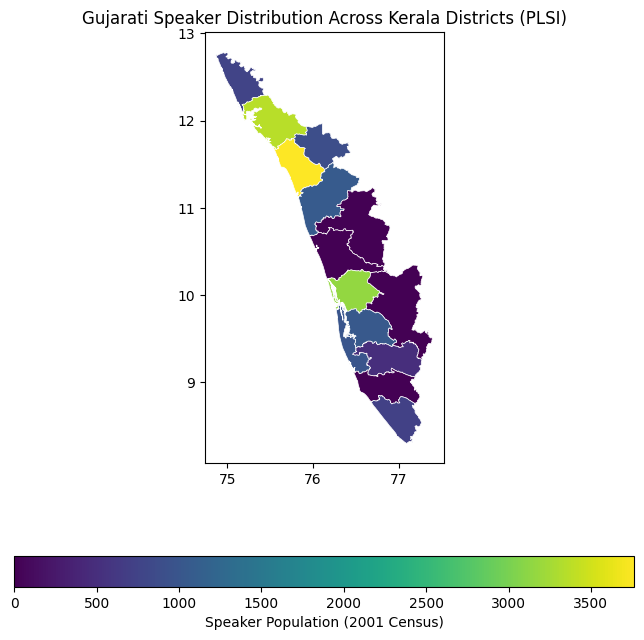

In [138]:
fig, ax = plt.subplots(figsize=(8,8))

merged_gujarati.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Gujarati Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Telugu 

In [139]:
telugu_dist_kerala_plsi_df = pd.read_csv("telugu_perc_district_mapping_2001_plsi.csv")
telugu_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Telugu,566,NaN
1,Kannur,Telugu,2333,NaN
2,Wayanad,Telugu,1866,NaN
3,Kozhikode,Telugu,2138,NaN
4,Malappuram,Telugu,2001,NaN
5,Palakkad,Telugu,21854,NaN
6,Thrissur,Telugu,3562,NaN
7,Ernakulam,Telugu,3951,NaN
8,Idukki,Telugu,2357,NaN
9,Kottayam,Telugu,1142,NaN


In [140]:
merged_telugu = all_districts.merge(telugu_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_telugu.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Telugu,566,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Telugu,2333,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Telugu,2138,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Telugu,1866,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Telugu,2001,NaN


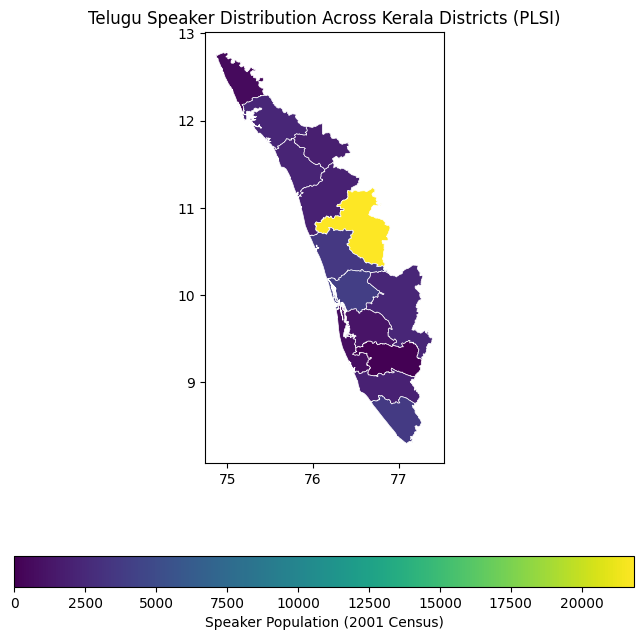

In [141]:
fig, ax = plt.subplots(figsize=(8,8))

merged_telugu.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Telugu Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Odiya 

In [142]:
odiya_dist_kerala_plsi_df = pd.read_csv("odiya_perc_district_mapping_2001_plsi.csv")
odiya_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Odiya,0,NaN
1,Kannur,Odiya,534,NaN
2,Wayanad,Odiya,0,NaN
3,Kozhikode,Odiya,0,NaN
4,Malappuram,Odiya,0,NaN
5,Palakkad,Odiya,0,NaN
6,Thrissur,Odiya,0,NaN
7,Ernakulam,Odiya,1222,NaN
8,Idukki,Odiya,0,NaN
9,Kottayam,Odiya,0,NaN


In [143]:
merged_odiya = all_districts.merge(odiya_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_odiya.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Odiya,0,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Odiya,534,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Odiya,0,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Odiya,0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Odiya,0,NaN


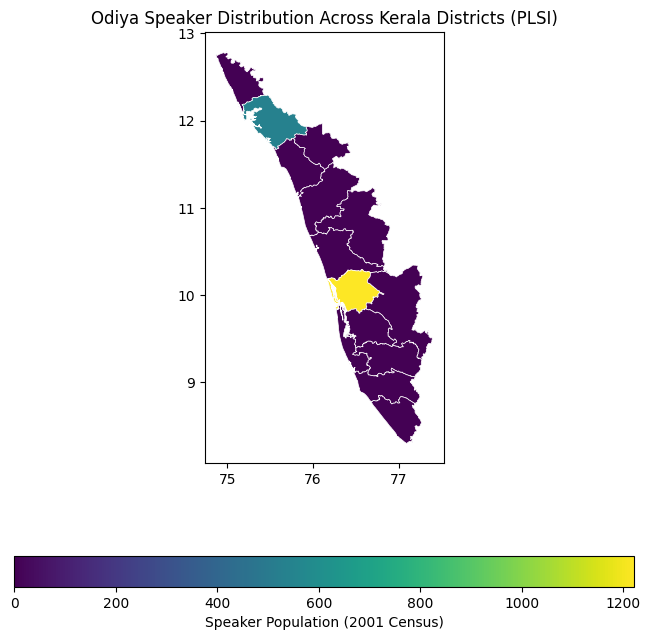

In [144]:
fig, ax = plt.subplots(figsize=(8,8))

merged_odiya.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Odiya Speaker Distribution Across Kerala Districts (PLSI)", fontsize=12
);

# Others 

In [145]:
others_dist_kerala_plsi_df = pd.read_csv("others_perc_district_mapping_2001_plsi.csv")
others_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Others,0,NaN
1,Kannur,Others,0,NaN
2,Wayanad,Others,0,NaN
3,Kozhikode,Others,0,NaN
4,Malappuram,Others,0,NaN
5,Palakkad,Others,14131,NaN
6,Thrissur,Others,0,NaN
7,Ernakulam,Others,548,NaN
8,Idukki,Others,0,NaN
9,Kottayam,Others,0,NaN


In [146]:
merged_others = all_districts.merge(others_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_others.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Others,0,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Others,0,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Others,0,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Others,0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Others,0,NaN


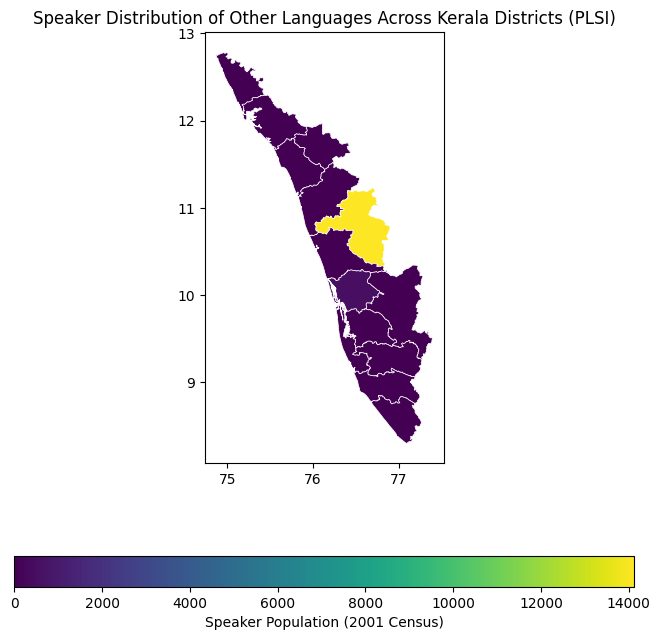

In [147]:
fig, ax = plt.subplots(figsize=(8,8))

merged_others.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Speaker Distribution of Other Languages Across Kerala Districts (PLSI)", fontsize=12
);

# English

In [148]:
english_dist_kerala_plsi_df = pd.read_csv("english_perc_district_mapping_2001_plsi.csv")
english_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,English,0.0,NaN
1,Kannur,English,0.0,NaN
2,Wayanad,English,0.0,NaN
3,Kozhikode,English,0.0,NaN
4,Malappuram,English,0.0,NaN
5,Palakkad,English,0.0,NaN
6,Thrissur,English,0.0,NaN
7,Ernakulam,English,2035.0,NaN
8,Idukki,English,0.0,NaN
9,Kottayam,English,0.0,NaN


In [149]:
merged_english = all_districts.merge(english_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_english.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,English,0.0,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,English,0.0,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,English,0.0,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,English,0.0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,English,0.0,NaN


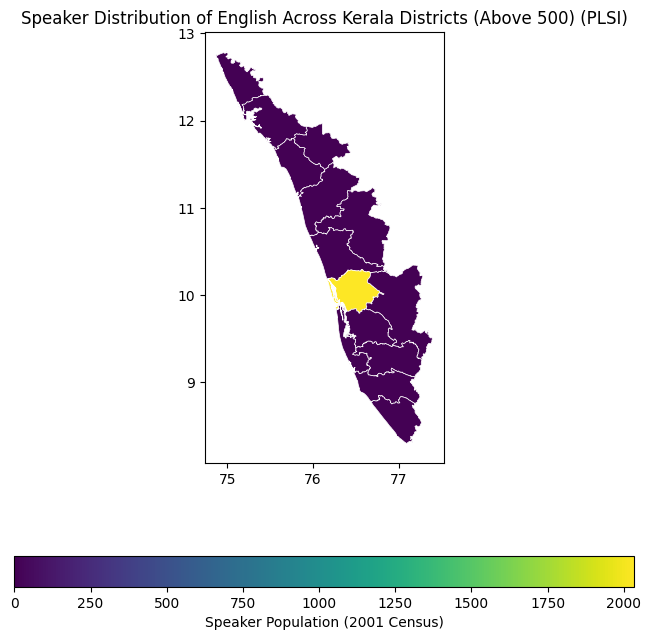

In [150]:
fig, ax = plt.subplots(figsize=(8,8))

merged_english.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Speaker Distribution of English Across Kerala Districts (Above 500) (PLSI)", fontsize=12
);

# Bengali

In [151]:
bengali_dist_kerala_plsi_df = pd.read_csv("bengali_perc_district_mapping_2001_plsi.csv")
bengali_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Bengali,0.0,NaN
1,Kannur,Bengali,0.0,NaN
2,Wayanad,Bengali,0.0,NaN
3,Kozhikode,Bengali,0.0,NaN
4,Malappuram,Bengali,0.0,NaN
5,Palakkad,Bengali,0.0,NaN
6,Thrissur,Bengali,0.0,NaN
7,Ernakulam,Bengali,1113.0,NaN
8,Idukki,Bengali,0.0,NaN
9,Kottayam,Bengali,0.0,NaN


In [152]:
merged_bengali = all_districts.merge(bengali_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_bengali.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Bengali,0.0,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Bengali,0.0,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Bengali,0.0,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Bengali,0.0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Bengali,0.0,NaN


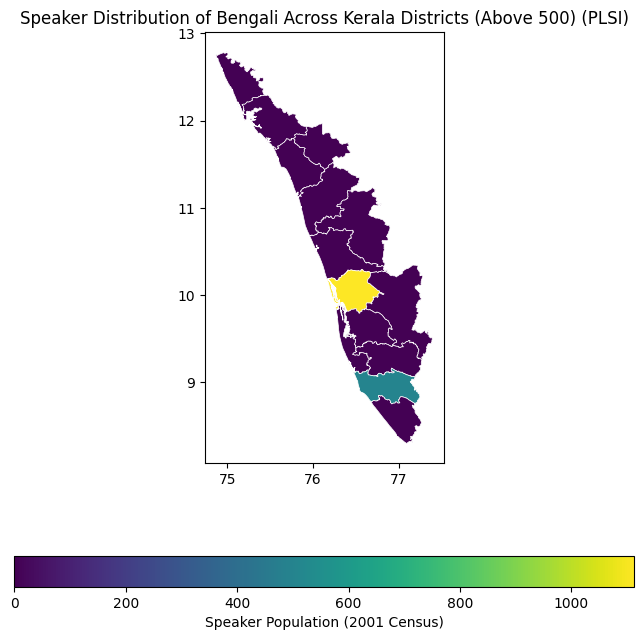

In [153]:
fig, ax = plt.subplots(figsize=(8,8))

merged_bengali.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Speaker Distribution of Bengali Across Kerala Districts (Above 500) (PLSI)", fontsize=12
);

# Nepali 

In [154]:
nepali_dist_kerala_plsi_df = pd.read_csv("nepali_perc_district_mapping_2001_plsi.csv")
nepali_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Nepali,0,NaN
1,Kannur,Nepali,0,NaN
2,Wayanad,Nepali,0,NaN
3,Kozhikode,Nepali,0,NaN
4,Malappuram,Nepali,0,NaN
5,Palakkad,Nepali,0,NaN
6,Thrissur,Nepali,0,NaN
7,Ernakulam,Nepali,0,NaN
8,Idukki,Nepali,0,NaN
9,Kottayam,Nepali,0,NaN


In [155]:
merged_nepali = all_districts.merge(nepali_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_nepali.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Nepali,0,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Nepali,0,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Nepali,0,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Nepali,0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Nepali,0,NaN


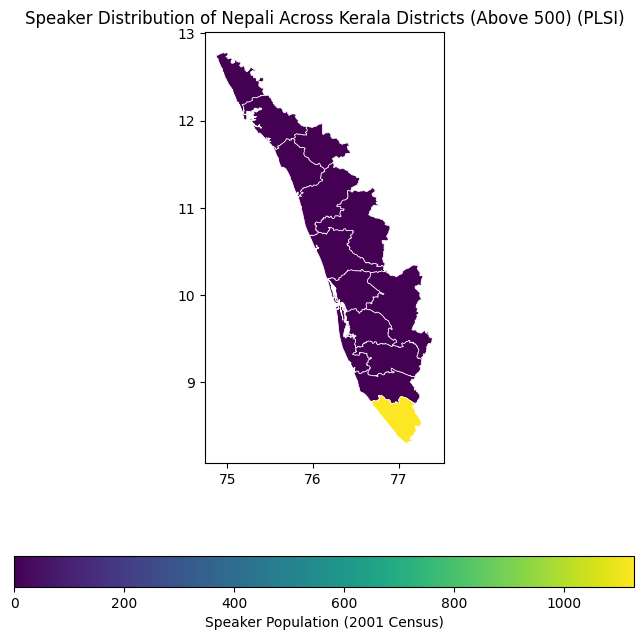

In [156]:
fig, ax = plt.subplots(figsize=(8,8))

merged_nepali.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Speaker Distribution of Nepali Across Kerala Districts (Above 500) (PLSI)", fontsize=12
);

In [157]:
# Forgot to include Sindhi and Punjabi (will do this later)

## Sindhi

In [158]:
sindhi_dist_kerala_plsi_df = pd.read_csv("sindhi_perc_district_mapping_2001_plsi.csv")
sindhi_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Sindhi,0,NaN
1,Kannur,Sindhi,0,NaN
2,Wayanad,Sindhi,0,NaN
3,Kozhikode,Sindhi,0,NaN
4,Malappuram,Sindhi,0,NaN
5,Palakkad,Sindhi,0,NaN
6,Thrissur,Sindhi,0,NaN
7,Ernakulam,Sindhi,951,NaN
8,Idukki,Sindhi,0,NaN
9,Kottayam,Sindhi,0,NaN


In [159]:
merged_sindhi = all_districts.merge(sindhi_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_sindhi.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Sindhi,0,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Sindhi,0,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Sindhi,0,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Sindhi,0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Sindhi,0,NaN


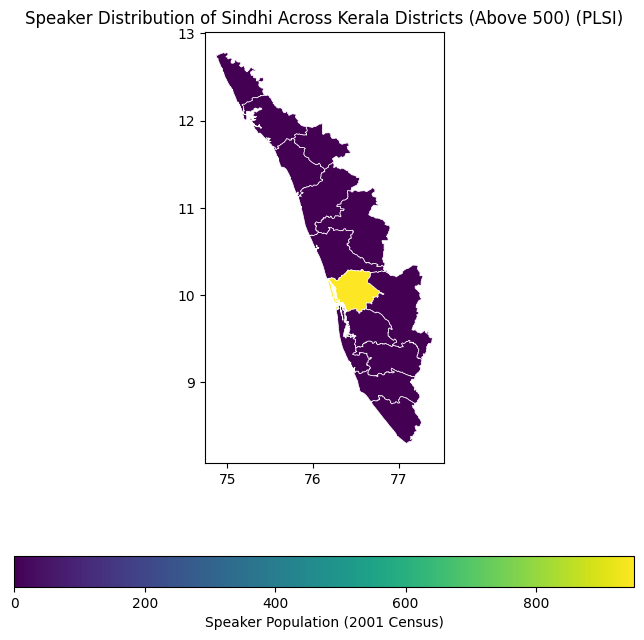

In [160]:
fig, ax = plt.subplots(figsize=(8,8))

merged_sindhi.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Speaker Distribution of Sindhi Across Kerala Districts (Above 500) (PLSI)", fontsize=12
);

## Punjabi

In [161]:
punjabi_dist_kerala_plsi_df = pd.read_csv("punjabi_perc_district_mapping_2001_plsi.csv")
punjabi_dist_kerala_plsi_df

,district,language,speakers,district_population
0,Kasaragod,Punjabi,0,NaN
1,Kannur,Punjabi,0,NaN
2,Wayanad,Punjabi,0,NaN
3,Kozhikode,Punjabi,0,NaN
4,Malappuram,Punjabi,0,NaN
5,Palakkad,Punjabi,0,NaN
6,Thrissur,Punjabi,0,NaN
7,Ernakulam,Punjabi,992,NaN
8,Idukki,Punjabi,0,NaN
9,Kottayam,Punjabi,0,NaN


In [162]:
merged_punjabi = all_districts.merge(punjabi_dist_kerala_plsi_df, left_on="NAME_2", right_on="district")
merged_punjabi.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,district,language,speakers,district_population
0,IND.17.5_1,IND,India,IND.17_1,Kerala,NA,Kasaragod,NA,NA,District,District,NA,IN.KL.KS,"MULTIPOLYGON (((75.1268 12.204, 75.1274 12.194...",Kasaragod,Punjabi,0,NaN
1,IND.17.4_1,IND,India,IND.17_1,Kerala,NA,Kannur,Cannanore,NA,District,District,NA,IN.KL.KN,"MULTIPOLYGON (((75.7429 12.0718, 75.7476 12.07...",Kannur,Punjabi,0,NaN
2,IND.17.8_1,IND,India,IND.17_1,Kerala,NA,Kozhikode,Calicut,NA,District,District,NA,IN.KL.KZ,"MULTIPOLYGON (((75.8385 11.134, 75.8363 11.128...",Kozhikode,Punjabi,0,NaN
3,IND.17.14_1,IND,India,IND.17_1,Kerala,NA,Wayanad,Wynaad|Wynad,NA,District,District,NA,IN.KL.WA,"MULTIPOLYGON (((76.1276 11.4491, 76.1142 11.46...",Wayanad,Punjabi,0,NaN
4,IND.17.9_1,IND,India,IND.17_1,Kerala,NA,Malappuram,NA,NA,District,District,NA,IN.KL.MA,"MULTIPOLYGON (((76.0233 10.8098, 76.0284 10.80...",Malappuram,Punjabi,0,NaN


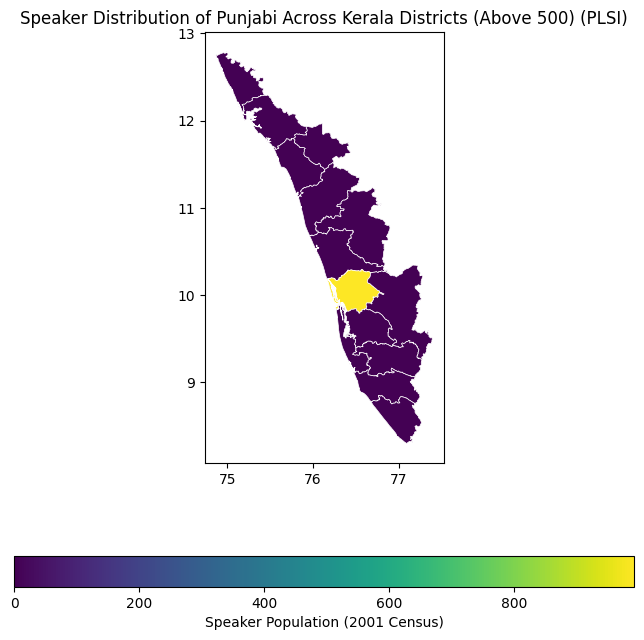

In [163]:
fig, ax = plt.subplots(figsize=(8,8))

merged_punjabi.plot(
    ax=ax,
    column="speakers",
    legend=True, 
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}

);

ax.set_title(
    "Speaker Distribution of Punjabi Across Kerala Districts (Above 500) (PLSI)", fontsize=12
);

### Next Figure: A Multiples map layout (4 x 4 grid-like) 

In [164]:
## Note: 

In [165]:
all_maps = [merged_malayalam, merged_tulu, merged_kannada, merged_marathi, merged_konkani, merged_urdu, merged_tamil, merged_hindi, merged_gujarati, merged_telugu, merged_odiya, merged_others, merged_english, merged_bengali, merged_nepali, merged_sindhi, merged_punjabi]                 

In [166]:
# list for each title of each map 
titles = ["Malayalam", "Tulu", "Kannada", "Marathi", "Konkani", "Urdu", "Tamil", "Hindi", "Gujarati", "Telugu", "Odiya", "Others", "English", "Bengali", "Nepali", "Sindhi", "Punjabi"]

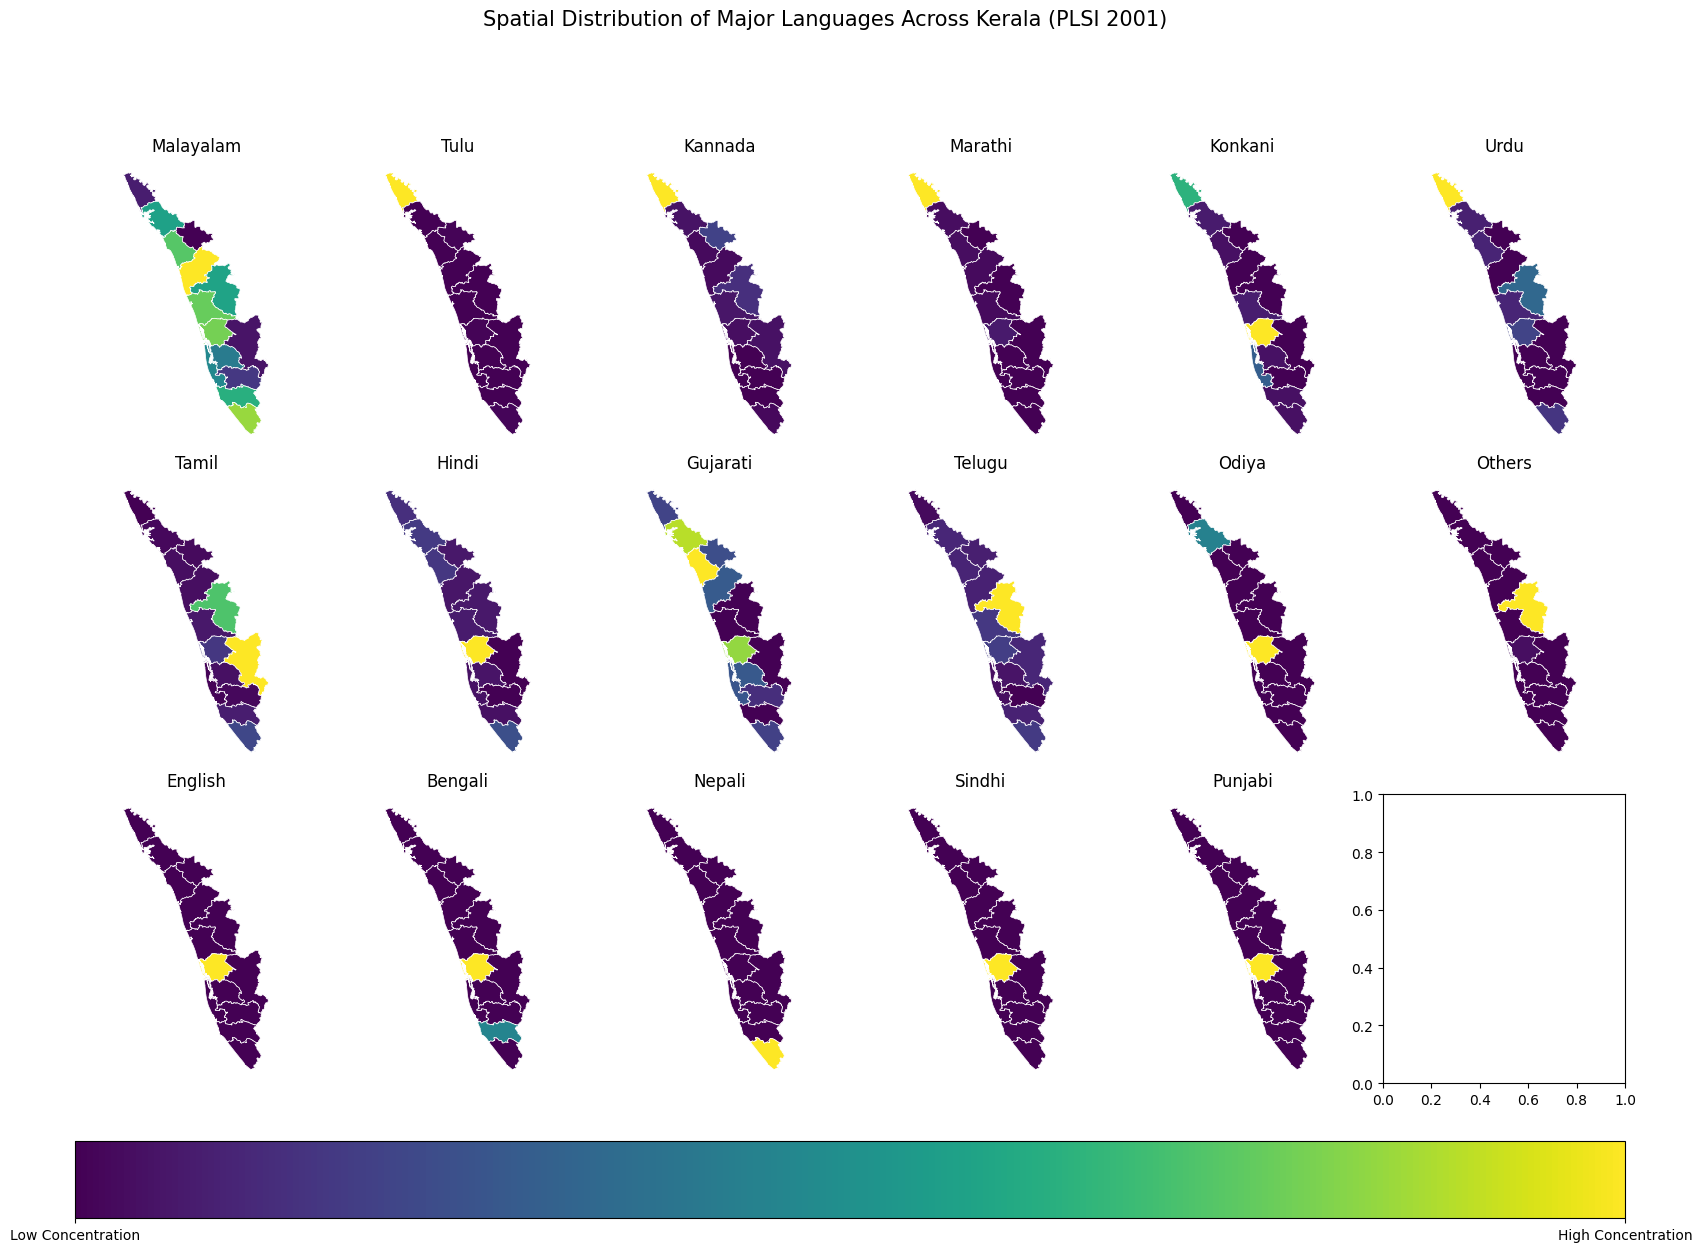

In [167]:
fig, ax = plt.subplots(3, 6, figsize=(20,15))

for map_data, title, subplot in zip(all_maps, titles, ax.flatten()):
    
    map_data.plot(
        ax=subplot,
        column="speakers",
        legend=False, 
        edgecolor="white",
        linewidth=0.5,
        legend_kwds={"label": "Speaker Population (2001 Census)", "orientation": "horizontal"}
    
    );
    
    subplot.set_title(title);
    subplot.axis('off')

#print(type(graph))

fig.subplots_adjust(wspace=0.08, hspace=0.1)
fig.suptitle("Spatial Distribution of Major Languages Across Kerala (PLSI 2001)", fontsize=15);

## adding a visual gradient

cmap = cm.viridis
#cax = ax.

# add a ScalarMappable object 
sm = cm.ScalarMappable(cmap=cmap)
cbar = fig.colorbar(sm, orientation="horizontal", ax=ax, pad=0.05, ticks=None);
cbar.set_ticks([0, 1], labels=['Low Concentration', 'High Concentration'])

#colorizer = mpl.colors.(cmap='viridis')

##### Note: Each language map uses its own color scale. Higher color intensity represents greater speaker concentration, but not equal speaker counts across each. 

### Bar Chart of Language Speaker Population Across Kerala (Not Including Malayalam)

In [168]:
top_fifteen_kerala_df = pd.read_csv("top_15_languages_kerala.csv")
top_fifteen_kerala_df

,language,speakers
0,Tamil,596971
1,Tulu,122995
2,Kannada,81406
3,Konkani,61376
4,Telugu,48633
5,Marathi,31845
6,Hindi,26386
7,Gujarati,17741
8,Others,16220
9,English,13492


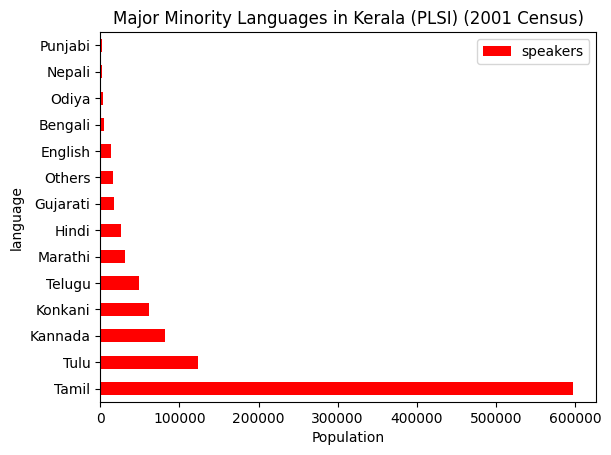

In [169]:
top_fifteen_kerala_df.plot.barh(x='language', y='speakers', title='Major Minority Languages in Kerala (PLSI) (2001 Census)', color='red');
plt.xlabel("Population");

### Bar Chart of Language Speaker Population Across Kerala (Including Malayalam)

In [170]:
top_fifteen_kerala_mal_df = pd.read_csv("top_15_languages_kerala_malayalam.csv")
top_fifteen_kerala_mal_df

,language,speakers
0,Malayalam,30803747
1,Tamil,596971
2,Tulu,122995
3,Kannada,81406
4,Konkani,61376
5,Telugu,48633
6,Marathi,31845
7,Hindi,26386
8,Gujarati,17741
9,Others,16220


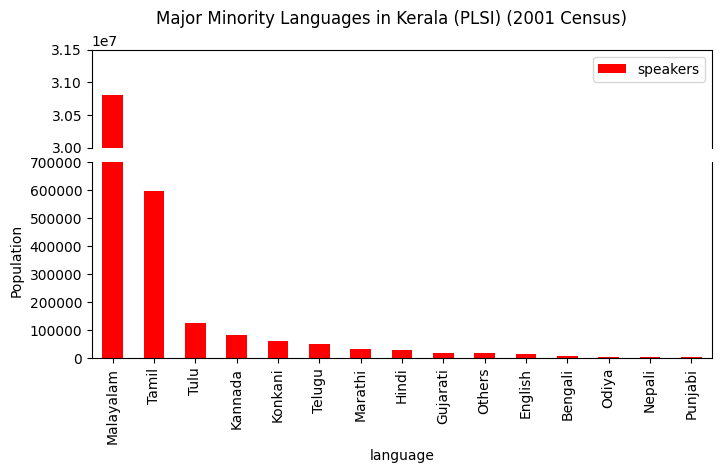

In [171]:
# broken axis creation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,4), gridspec_kw={'height_ratios':[2,4]})

top_fifteen_kerala_mal_df.plot.bar(ax=ax1, y='speakers', color='red');
top_fifteen_kerala_mal_df.plot.bar(ax=ax2, x='language', y='speakers', color='red');

ax1.set_ylim(30000000, 31500000)
ax2.set_ylim(0, 700000)

fig.suptitle('Major Minority Languages in Kerala (PLSI) (2001 Census)')
plt.ylabel("Population");
fig.subplots_adjust(hspace=0.1)
ax1.set_xlabel("")
ax1.spines['bottom'].set_visible(False)
ax2.legend().remove()
ax1.tick_params(labelbottom=False, bottom=False)
ax2.spines['top'].set_visible(False)

In [172]:
print(ax1.get_ylim())
print(ax2.get_ylim())

(np.float64(30000000.0), np.float64(31500000.0))
(np.float64(0.0), np.float64(700000.0))


#### Language Proportions by Kerala Districts Bar Chart

In [173]:
## will add more languages
kerala_lang_prop_df = pd.read_csv("kerala_language_proportion.csv")
kerala_lang_prop_df

,Districts,Malayalam,Tamil,Tulu,Telugu,Kannada,Marathi,Konkani,Urdu,Gujarati,Hindi,Odiya,Others,English,Bengali,Nepali
0,Kasaragod,979827,5065,116919,566,50575,24382,17199,6297,752,1671,0,0,0,0,0
1,Kannur,2383901,9560,0,2333,2512,768,1895,548,3364,2102,534,0,0,0,0
2,Wayanad,754116,10172,982,1866,9948,0,0,0,889,799,0,0,0,0,0
3,Kozhikode,2852482,13298,0,2138,1238,842,1120,623,3764,1922,0,0,0,0,0
4,Malappuram,3604887,13264,0,2001,1276,591,0,0,1059,683,0,0,0,0,0
5,Palakkad,2408847,160991,0,21854,6785,0,0,2098,0,778,0,14131,0,0,0
6,Thrissur,2943407,18772,0,3562,2767,643,2170,654,0,894,0,0,0,0,0
7,Ernakulam,3006860,39013,1271,3951,1869,1680,26820,1271,3152,12276,1222,548,2035,1113,0
8,Idukki,900907,221734,0,2357,2245,0,0,0,0,0,0,0,0,0,0
9,Kottayam,1933792,13940,0,1142,0,0,1232,0,1041,653,0,0,0,0,0


In [174]:
kerala_lang_prop_df = kerala_lang_prop_df.set_index("Districts")

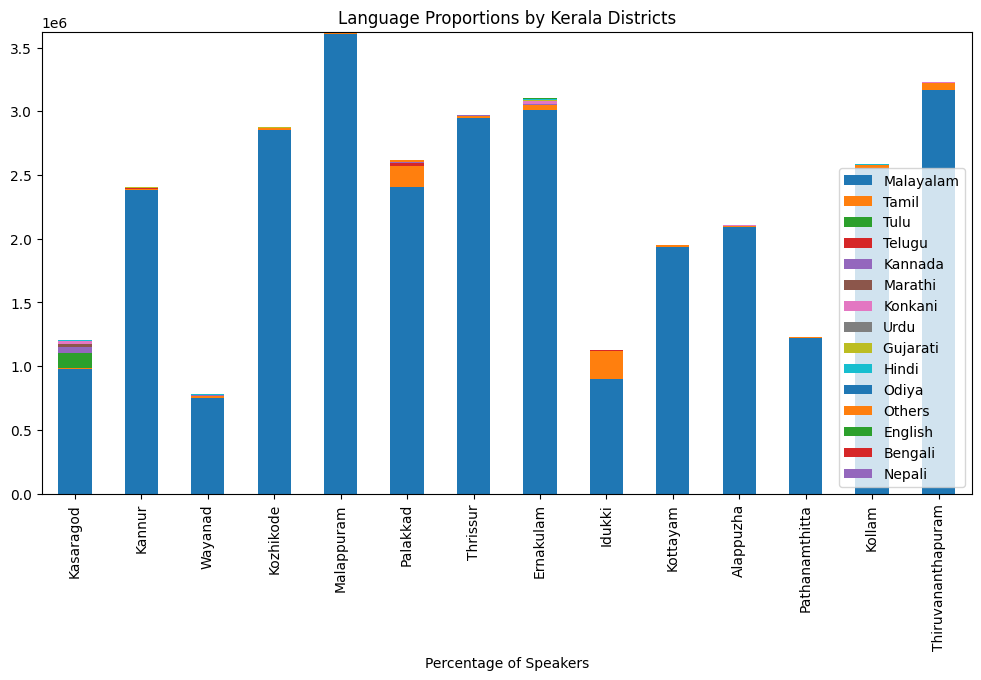

In [175]:
ax = kerala_lang_prop_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Language Proportions by Kerala Districts")
plt.xlabel("District")
plt.xlabel("Percentage of Speakers");

In [176]:
### Need to make this a 100% Stacked Bar Chart 

### Pie Chart of Malayalam Speaker Population Distribution Across Kerala

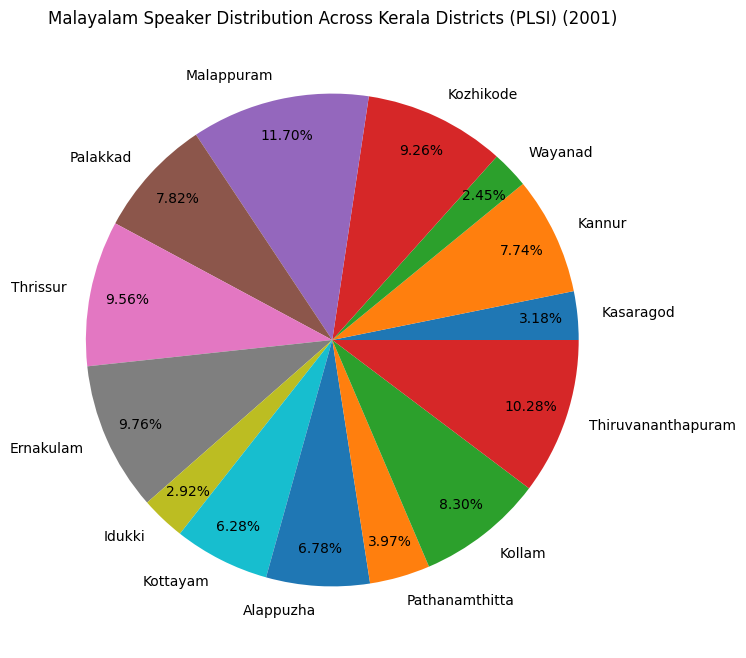

In [177]:
## plotting 14 districts in a pie chart could be quite difficult with so many pieces
fig, ax= plt.subplots(figsize=(8,8))

mal_dist_kerala_plsi_df.plot.pie(
    
    ax=ax, y="speakers", labels=mal_dist_kerala_plsi_df["district"], autopct='%1.2f%%', legend=False, pctdistance=.85
)

ax.set_title(
    "Malayalam Speaker Distribution Across Kerala Districts (PLSI) (2001)", fontsize=12
);

In [178]:
### Now plotting relationship between total district populations and Malayalam speaker populations using censusindia.gov

### My aim is to see if the speaker count scales proportionally with the district population or if a district is over/underrepresented

In [179]:
## Can possibly do this with a scatter plot or a residual plot? or another chloropleth? 

In [181]:
## Let's try scatter plot 
mal_proportion_df = pd.read_csv("malayalam_perc_district_mapping_popl_plsi.csv")
mal_proportion_df

,district,language,speakers,district_population
0,Kasaragod,Malayalam,979827,1204078
1,Kannur,Malayalam,2383901,2408956
2,Wayanad,Malayalam,754116,780619
3,Kozhikode,Malayalam,2852482,2879131
4,Malappuram,Malayalam,3604887,3625471
5,Palakkad,Malayalam,2408847,2617482
6,Thrissur,Malayalam,2943407,2974232
7,Ernakulam,Malayalam,3006860,3105798
8,Idukki,Malayalam,900907,1129221
9,Kottayam,Malayalam,1933792,1953646


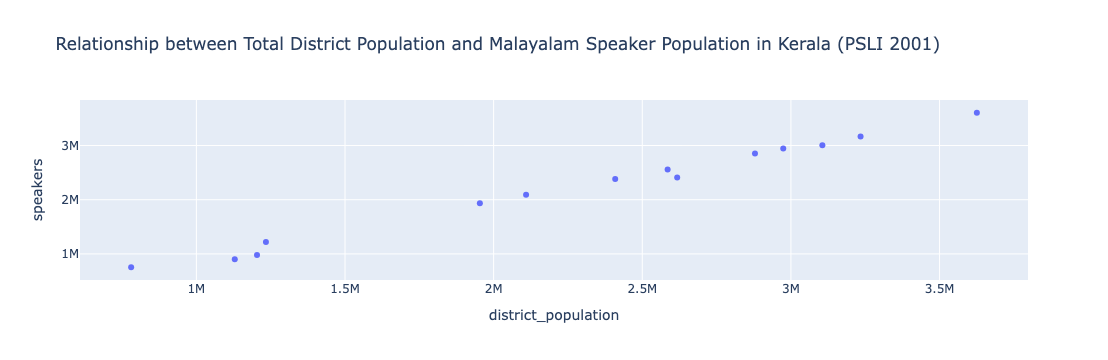

In [197]:
## creating the scatter plot 
px.scatter(mal_proportion_df, x="district_population", y="speakers", hover_name="district", title="Relationship between Total District Population and Malayalam Speaker Population in Kerala (PSLI 2001)")